# Libraries

In [ ]:
import urllib.request
import numpy as np
import pandas as pd

!pip install onedrivedownloader
!pip install SciencePlots

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','ieee','no-latex'])

In [ ]:
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = (cycler('color', ['k', 'r', 'b', 'g','m','c','orange'])
                                   + cycler('linestyle', ['-', '--', ':', '-.',(0, (3, 3, 1, 3, 1, 3)),(0, (3, 3, 1, 1, 1, 1, 1, 3)),(0, (3, 3, 1, 0.5, 1, 0.5))]))

In [ ]:
def plot(graph, bridges: dict, title: str, xlim, ylim):
    for bridge, label in bridges.items():
        df_bridge = df[bridge]
        graph.plot(df_bridge['x'], df_bridge['y'], label=label)

    graph.set(title = title)
    graph.set(xlabel = 'Displacement ($mm$)')
    graph.set(ylabel = 'Force ($kN$)')

    graph.set_xlim(xlim)
    graph.set_ylim(ylim)

    graph.legend()

# Results

In [ ]:
from onedrivedownloader import download

# Your OneDrive shared link
onedrive_link = "https://1drv.ms/x/c/383d0032d2d3546b/EWtU09IyAD0ggDilAwAAAAABHJkpuGP-W4MeOn7VIapfqg?e=bKwAaM"

# Desired filename to save the downloaded file
filename = "results.xlsx"

# Download the file
download(onedrive_link, filename=filename)

In [ ]:
# Path to Excel file
file_path = "results.xlsx"

# Specify the sheet name
sheet_name = 'Results'

# Read the sheet into a DataFrame
df = pd.read_excel(file_path, skiprows=2, header=[0, 1])

df.head()

# The behaviour of multiring brickwork arch bridges

##Bridge 3.1

In [ ]:
bridges = {'3.1_Experimental': 'Experimental',
           'Bridge_3.1_Coarse': 'Coarse mesh',
           'Bridge_3.1_Multiring': 'Fine mesh',
           'Bridge_3.1_Zhang': 'Zhang et al. (2018)',
           'LimitAnalysis_3.1': 'Gilbert et al. (2025)',
           }

fig, graph = plt.subplots()
plot(graph, bridges, 'Bridge 3.1', [0,10], [0,600])

graph.plot()

#fig.savefig("bridge_3.1.pdf", bbox_inches = 'tight', pad_inches = 0);

In [ ]:
bridges = {'3.1_Experimental': 'Experimental',
           'Bridge_3.1_Coarse': 'Coarse mesh',
           'Bridge_3.1_Multiring': 'Fine mesh',
           'Bridge_3.1_transversalElements_border': '8 elements along the width | Border',
           'Bridge_3.1_transversalElements': '8 elements along the width | Middle',

           }

fig, graph = plt.subplots()
plot(graph, bridges, 'Bridge 3.1 - mesh sensitivity', [0,10], [0,600])

graph.plot()

#fig.savefig("bridge_3.1.pdf", bbox_inches = 'tight', pad_inches = 0);

In [ ]:
bridges = {
    # '3.1_Experimental': 'Experimental',
    'Bridge_3.1_transversalElements_Unconnected': 'Old DMEM',
    'Bridge_3.1_transversalElements': 'Novel DMEM',
}

fig, graph = plt.subplots()
plot(graph, bridges, 'Transversally coupled and uncoupled', [0,10], [0,600])

graph.plot()

#fig.savefig("bridge_3.1.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 3.2

In [ ]:
bridges = {'Bridge_3.2_Experimental': 'Experimental',
           'Bridge_3.2_Sand': 'Numerical'}

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.2', [0,15], [0,500])

#fig.savefig("bridge_3.2.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 3.3

In [ ]:
bridges = {'3.3_Experimental': 'Experimental',
           '3.3_FEM (Zhang)': 'Zhang et al. (2018)',
           #'Bridge_3.1_Coarse_extended',
           #'3-3_Fine_3loads_multiring',
           #'3-3_standard': 'Default',
           #'3-3_Fine_3loads_multiring_detached',
           #'3-3_Fine_3loads_detached',
           #'3-3_detached(Young/cohesion)',
           #'3-3_playing',
           #'3-4',
           #'3-3_Numerical_4_Zhang_tol_0.0001': 'Two elements (tol=0.0001)',
           #'3.3_Numerical_drucker': 'Numerical',
           '3.3_Numerical_drucker_z': 'DMEM',
           '3.3_Histra2026.1': 'DMEM - 2026.1',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.3', [0,3], [0,800])

#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

In [ ]:
bridges = {'3.3_Experimental': 'Experimental',
           '3.3_FEM (Zhang)': 'Zhang et al. (2018)',
           '3.3_Numerical_drucker_z': 'DMEM',
           }

df_bridge = df['Bridge_3.3_Transversal_displacement_strips'][:215]

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.3', [0,4], [0,800])

graph.plot(df_bridge['Center'], df_bridge['Load'], label="Previous DMEM formulation")
graph.legend()

plt.legend(fontsize=6)

#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);


### Transversal Displacment

In [ ]:
df_bridge = df['Bridge_3.3_Transversal_displacement'][:169]

# df_bridge = df_bridge[df_bridge['Center'] > -1.6]

steps = [18, 44, 65, 87, 116]

fig, graph = plt.subplots()

spandrel_loc = (3540-330)/2
fill_loc = (3540/2-330-1300)/2+1300
print(f"{spandrel_loc=}")
print(f"{fill_loc=}")

for step in steps:
    center = df_bridge.iloc[step]['Center']
    fill = df_bridge.iloc[step]['Fill']
    spandrel = df_bridge.iloc[step]['Spandrel']
    load = df_bridge.iloc[step]['Load']


    graph.plot([-spandrel_loc,-fill_loc,-1300/2,1300/2,fill_loc,spandrel_loc], [spandrel, fill, center, center, fill, spandrel], label=str(int(load))+ ' kN')

x = np.array([0, 499, 998, 1498, 1770])

# #200
# y = np.array([-0.061971831, -0.095774648, -0.132394366, -0.146478873, -0.146478873])
# graph.plot(-x, np.flip(y),'--', color='gray')
# graph.plot(x, np.flip(y),'--', color='gray')

# #400
# y = np.array([-0.163380282, -0.23943662, -0.312676056, -0.346478873, -0.346478873])
# graph.plot(-x, np.flip(y),'--', color='gray')
# graph.plot(x, np.flip(y),'--', color='gray')

# #500
# y = np.array([-0.242253521, -0.363380282, -0.461971831, -0.512676056, -0.515492958])
# graph.plot(-x, np.flip(y),'--', color='gray')
# graph.plot(x, np.flip(y),'--', color='gray')

# #600
# y = np.array([-0.354929577, -0.512676056, -0.653521127, -0.723943662, -0.732394366])
# graph.plot(-x, np.flip(y),'--', color='gray')
# graph.plot(x, np.flip(y),'--', color='gray')

# #650
# y = np.array([-0.447887324, -0.653521127, -0.864788732, -1.008450704, -1.022535211])
# graph.plot(-x, np.flip(y),'--', color='gray')
# graph.plot(x, np.flip(y),'--', color='gray')

#680
y = np.array([-0.591549296, -0.898591549, -1.236619718, -1.436619718, -1.45915493])
graph.plot(-x, np.flip(y),'--', color='gray', label='680 kN\nZhang et al. (2018)')
graph.plot(x, np.flip(y),'--', color='gray')


# graph.plot([(3540-2*330)/2,(3540-2*330)/2], [0,-2],'-', color='black')
# graph.plot([-(3540-2*330)/2,-(3540-2*330)/2], [0,-2],'-', color='black')

# graph.plot([1300,1300], [0,-2],'-', color='black')
# graph.plot([-1300,-1300], [0,-2],'-', color='black')

graph.set(title ='Bridge 3.3 - Displacements along the width')
graph.set(xlabel ='Trasnversal ($mm$)')
graph.set(ylabel ='Displacment ($mm$)')

graph.set_xlim([-3540/2,3540/2])
graph.set_ylim([-1.5, 0])

graph.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# df_bridge

In [ ]:
n_steps = 214 + 1

df_bridge = df['Bridge_3.3_Transversal_displacement_strips'][:n_steps]

steps = [int(.1*n_steps), int(.25*n_steps), int(.5*n_steps), int(.75*n_steps), int(n_steps-1)]

fig, graph = plt.subplots()


for step in steps:
    center   = -1 * df_bridge.iloc[step]['Center']
    fill     = -1 * df_bridge.iloc[step]['Fill']
    spandrel = -1 * df_bridge.iloc[step]['Spandrel']
    load     =      df_bridge.iloc[step]['Load']

    points = [
        (-1770, spandrel),
        (-1440, spandrel),
        (-1440, fill),
        (-1300, fill),
        (-1300, center),
        (1300, center),
        (1300, fill),
        (1440, fill),
        (1440, spandrel),
        (1770, spandrel),
    ]

    x_vals, y_vals = zip(*points)

    graph.plot(x_vals, y_vals, label=f"{int(load)} kN")


# graph.plot([-1770, -1770], [-4, 0.1])

graph.set(title ='Bridge 3.3 - Displacements along the width (strips)')
graph.set(xlabel ='Trasnversal ($mm$)')
graph.set(ylabel ='Displacment ($mm$)')

# graph.set_xlim([-3540/2,3540/2])
# graph.set_ylim([-1.5, 0])

graph.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# df_bridge
spandrel_loc, fill_loc

### Zhang

In [ ]:
bridges = {'3.3_FEM (Zhang)': 'Zhang et al. (2018)',
           #'3.3_2_lines',
           #'3-3_Numerical_2_Zhang',
           #'3-3_Numerical_4_Zhang',
           #'3-3_Numerical_2_Zhang_tol_0.001': 'Two elements (tol=0.001)',
           #'3-3_Numerical_2_Zhang_tol_0.001_plate': 'Two elements (tol=0.001) - Plate',
           #'3-3_Numerical_4_Zhang_tol_0.001': 'Four elements (tol=0.001)',
           #'3-3_Numerical_4_Zhang_tol_0.0001': 'Two elements (tol=0.0001)',
           #'3-3_Numerical_8_Zhang_tol_0.001': 'Eight elements (tol=0.001)',
           #'3-3_Numerical_8_Zhang_tol_0.0001': 'Eight elements (tol=0.0001)',
           '3-3_Numerical_2_Zhang_tol_0.0001_fric0.5': 'Two elements (tol=0.0001) - fric=0.5'
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.3 - Zhang properties', [0,5], [0,1200])

#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

#### Tensile

In [ ]:
bridges = {#'3.3_FEM (Zhang)': 'Zhang et al. (2018)',
           #'3.3_2_lines': 'Two elements',
           #'3-3_Numerical_2_Zhang_0.100',
           '3-3_Numerical_2_Zhang_tol_0.001': 'ft = 0.2',
           '3-3_Numerical_2_Zhang_tol_0.001_0.174': 'ft = 0.174',
           '3-3_Numerical_2_Zhang_tol_0.001_0.100': 'ft = 0.1',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.3 - Tensile sensitivity', [0,5], [0,900])

#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

### Tranversal division

In [ ]:
bridges = ['3.3_1_lines',
           '3.3_2_lines',
           '3.3_4_lines',
           '3.3_8_lines'
           ]

fig, graph = plt.subplots()

for bridge in bridges:
  df_bridge = df[bridge]
  graph.plot(df_bridge['x'], df_bridge['y'], label=bridge)

graph.set(title ='Bridge 3.3 - Mesh sensitivity')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([0,5])
graph.set_ylim([0,1200])

graph.legend()
#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

#### Tolerance

In [ ]:
bridges = {'3.3_4_lines': 'Four elements',
           '3.3_4_lines_tol_0.001': 'Four elements (tol= 0.001)',
           '3.3_4_lines_tol_0.0001': 'Four elements (tol= 0.0001)',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.3 - Tolerance sensitivity', [0,5], [0,1200])

#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

### Spandrel division

In [ ]:
bridges = {
    '3.3_2_lines': '1 element in the spandrel wall',
    '3.3_spandrel_2': '2 elements in the spandrel wall',
}

fig, graph = plt.subplots()
plot(graph, bridges, 'Bridge 3.3 - Mesh sensitivity of spandrel wall', [0,5], [0,1200])

graph.plot()

### Plate

In [ ]:
bridges = ['3.3_4_lines_NoPlate',
           '3.3_4_lines_Plate',
           ]

fig, graph = plt.subplots()

for bridge in bridges:
  df_bridge = df[bridge]
  graph.plot(df_bridge['x'], df_bridge['y'], label=bridge)

graph.set(title ='Bridge 3.3 - Mesh sensitivity')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([0,5])
graph.set_ylim([0,1200])

graph.legend()
#fig.savefig("bridge_3.3.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 3.4

In [ ]:
bridges = {'Bridge_3.4_Experimental': 'Experimental',
        #    '3-4_Numerical': 'Numerical',
           '3-4_Numerical_new': 'Numerical (3.4)',
        #    '3-3_Numerical_2_Zhang_tol_0.0001_fric0.5': 'Numerical (3.3)',
           '3.3_Numerical_drucker_z': 'Numerical (3.3)',
           'Bridge_3.2_extended': 'Numerical (3.2) - Scaled',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3.4', [0,4], [0,800])

graph.legend(prop={'size': 7})

#fig.savefig("bridge_3.4.pdf", bbox_inches = 'tight', pad_inches = 0);
max(df['3-4_Numerical_new']['y'])

In [ ]:
n_steps = 172 + 1

df_bridge = df['Bridge_3.4_Transversal_displacement'][:n_steps]

steps = [int(.1*n_steps), int(.25*n_steps), int(.5*n_steps), int(.75*n_steps), int(n_steps-1)]

fig, graph = plt.subplots()

spandrel_loc = (3540-330)/2
fill_loc = (3540/2-330-1300)/2+1300
# print(f"{spandrel_loc=}")
# print(f"{fill_loc=}")

for step in steps:
    center   = -1 * df_bridge.iloc[step]['Center']
    fill     = -1 * df_bridge.iloc[step]['Fill']
    spandrel = -1 * df_bridge.iloc[step]['Spandrel']
    load     =      df_bridge.iloc[step]['Load']
    graph.plot(
        [-spandrel_loc,-fill_loc,-1300/2,1300/2,fill_loc,spandrel_loc],
        [spandrel, fill, center, center, fill, spandrel],
        label=str(int(load))+ ' kN')

# x = np.array([0, 499, 998, 1498, 1770])

#680
# y = np.array([-0.591549296, -0.898591549, -1.236619718, -1.436619718, -1.45915493])
# graph.plot(-x, np.flip(y),'--', color='gray', label='680 kN\nZhang et al. (2018)')
# graph.plot(x, np.flip(y),'--', color='gray')


graph.set(title ='Bridge 3.4 - Displacements along the width')
graph.set(xlabel ='Trasnversal ($mm$)')
graph.set(ylabel ='Displacment ($mm$)')

# graph.set_xlim([-3540/2,3540/2])
# graph.set_ylim([-1.5, 0])

graph.legend(loc='center left', bbox_to_anchor=(1, 0.5))
df_bridge

In [ ]:
n_steps = 311 + 1

df_bridge = df['Bridge_3.4_Transversal_displacement'][:n_steps]

steps = [int(.1*n_steps), int(.25*n_steps), int(.5*n_steps), int(.75*n_steps), int(n_steps-1)]

fig, graph = plt.subplots()

spandrel_loc = (3540-330)/2
fill_loc = (3540/2-330-1300)/2+1300
# print(f"{spandrel_loc=}")
# print(f"{fill_loc=}")

for step in steps:
    spandrel = -1 * df_bridge.iloc[step]['Spandrel']
    center   = 1 * (df_bridge.iloc[step]['Center'] + spandrel) / spandrel
    fill     = 1 * (df_bridge.iloc[step]['Fill'] + spandrel) / spandrel
    spandrel  -= spandrel
    load     =      df_bridge.iloc[step]['Load']
    graph.plot(
        [-spandrel_loc,-fill_loc,-1300/2,1300/2,fill_loc,spandrel_loc],
        [spandrel, fill, center, center, fill, spandrel],
        label=str(int(load))+ ' kN')

# x = np.array([0, 499, 998, 1498, 1770])

#680
# y = np.array([-0.591549296, -0.898591549, -1.236619718, -1.436619718, -1.45915493])
# graph.plot(-x, np.flip(y),'--', color='gray', label='680 kN\nZhang et al. (2018)')
# graph.plot(x, np.flip(y),'--', color='gray')


graph.set(title ='Bridge 3.4 - Displacements along the width')
graph.set(xlabel ='Trasnversal ($mm$)')
graph.set(ylabel ='Displacment ($mm$)')

# graph.set_xlim([-3540/2,3540/2])
# graph.set_ylim([-1.5, 0])

graph.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Bridge 5.1

In [ ]:
fig, graph = plt.subplots()

df_bridge = df['Bridge_5.1_Experimental']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental')

# df_bridge = df['Bridge_5.1_Numerical']
# # radial_disp = 0.916516*df_bridge['z'] + 0.399998*df_bridge['x']
# radial_disp = df_bridge['z']
# graph.plot(radial_disp, df_bridge['f'], label='Original model (strip model)')

df_bridge = df['Bridge_5.1_Masonry_new'].dropna()[:-17]
graph.plot(df_bridge['x'], df_bridge['y'], label='Original model (strip model)')

df_bridge = df['Bridge_5.1_Load_spandrel']
graph.plot(df_bridge['x'], df_bridge['y'], label='Revised model')

# df_bridge = df['Bridge_5.1_Load_spandrel_new']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Bridge_5.1_Load_spandrel_new')


df_bridge = df['LimitAnalysis_5.1']
graph.plot(df_bridge['x'], df_bridge['y'], label='Gilbert et al. (2025)')

graph.set(title ='Bridge 5.1')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([0,13])
graph.set_ylim([0,2000])

graph.legend()
#fig.savefig("bridge_5.1.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 5.2

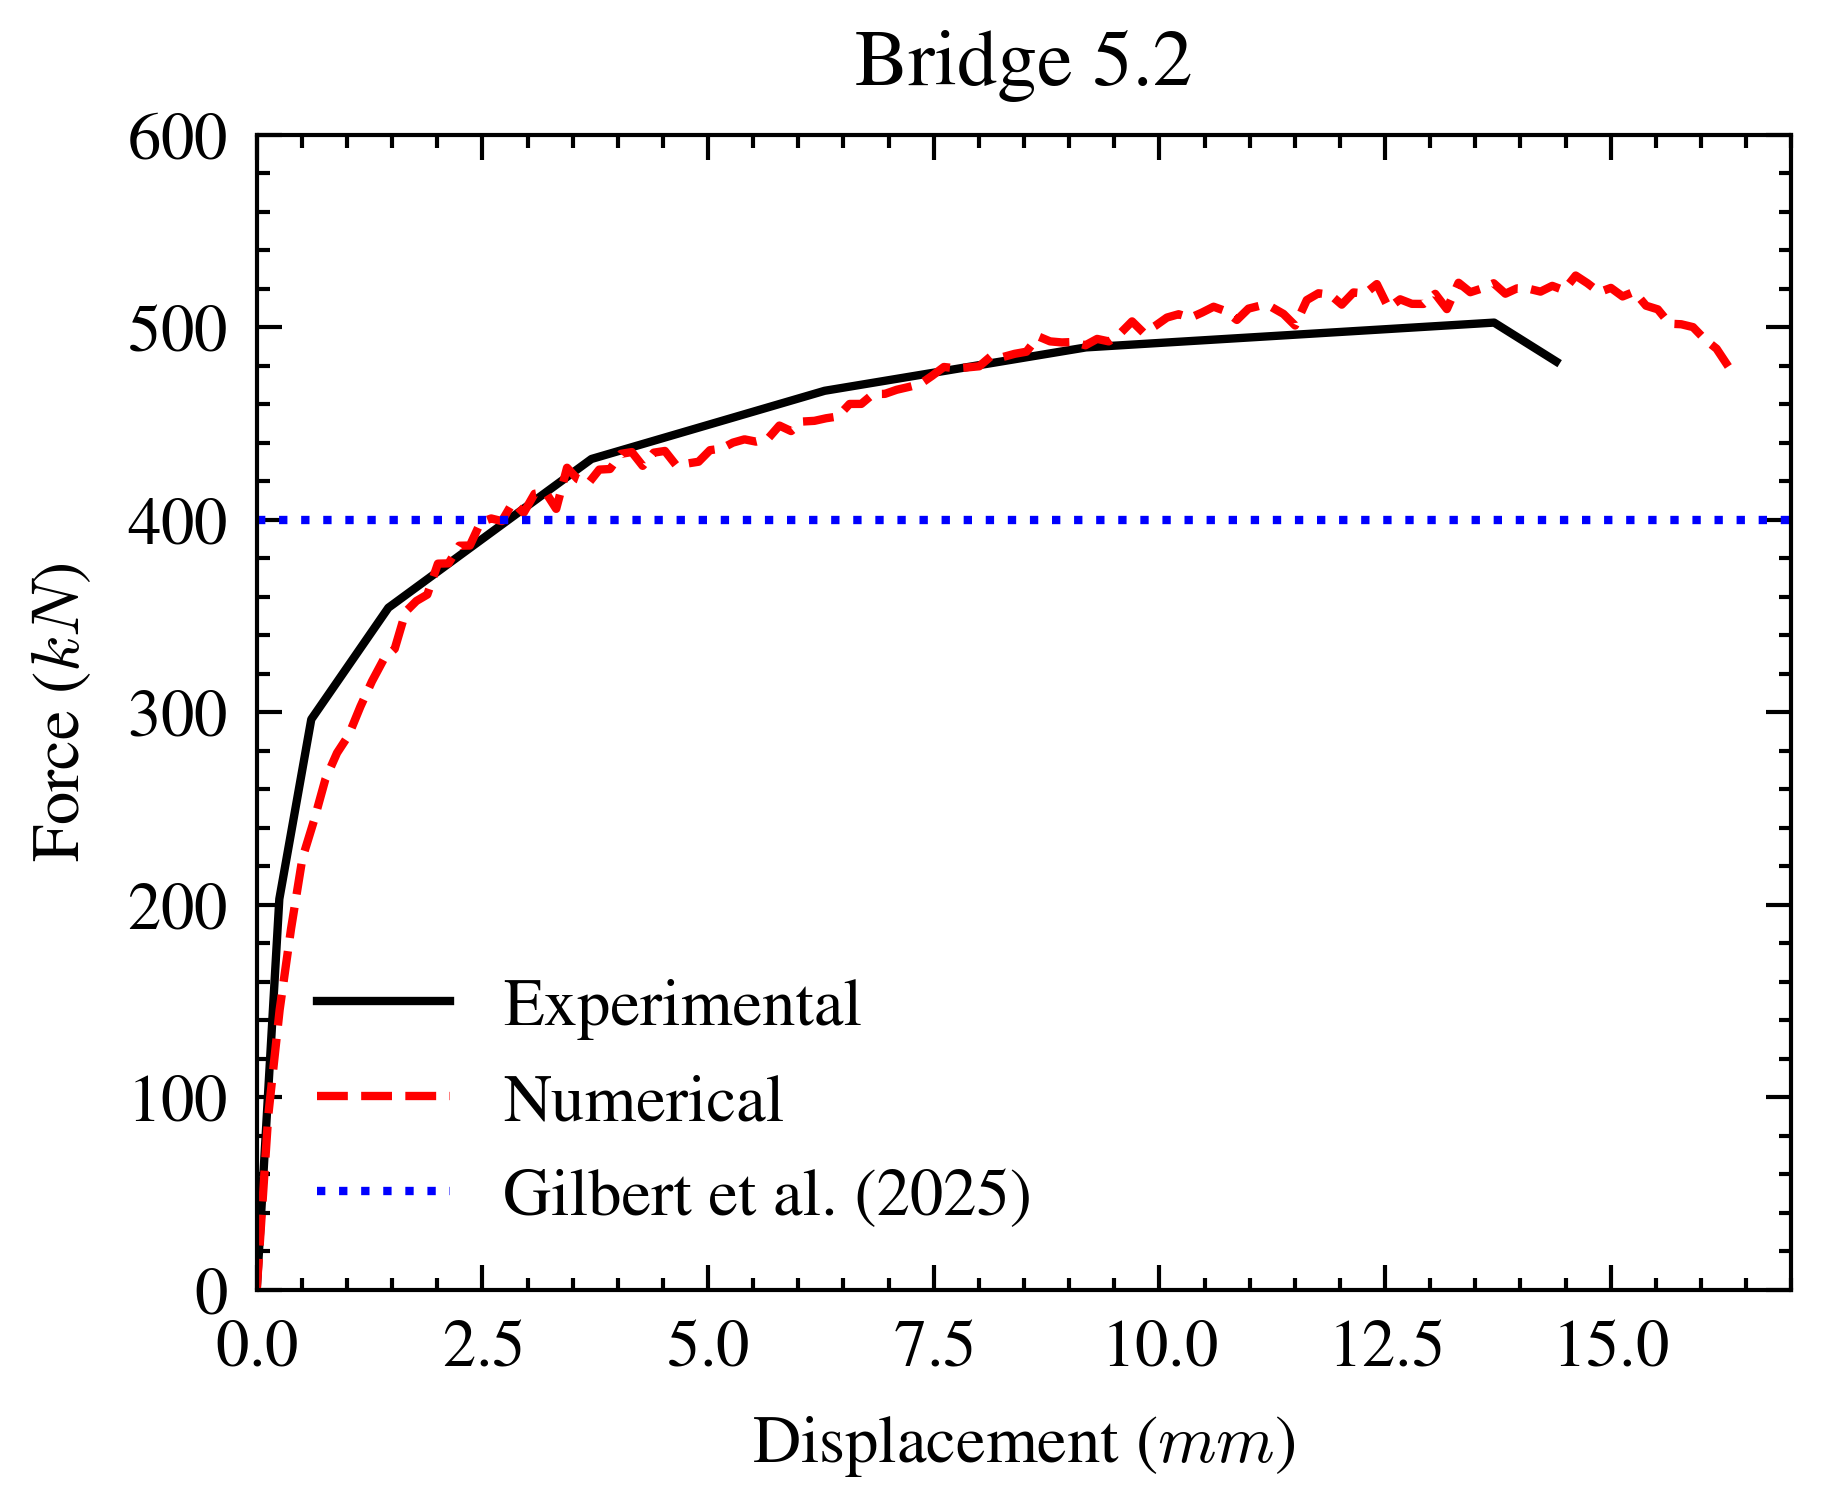

In [ ]:
bridges = {
    'Bridge_5.2_Experimental': 'Experimental',
    'Bridge_5.2_Numerical_Coarse': 'Numerical',
    'LimitAnalysis_5.2': 'Gilbert et al. (2025)'
    }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 5.2', [0,17], [0,600])

#fig.savefig("bridge_5.2.pdf", bbox_inches = 'tight', pad_inches = 0);

# The collapse behaviour of multispan brickwork arch bridges

## Bridge 1

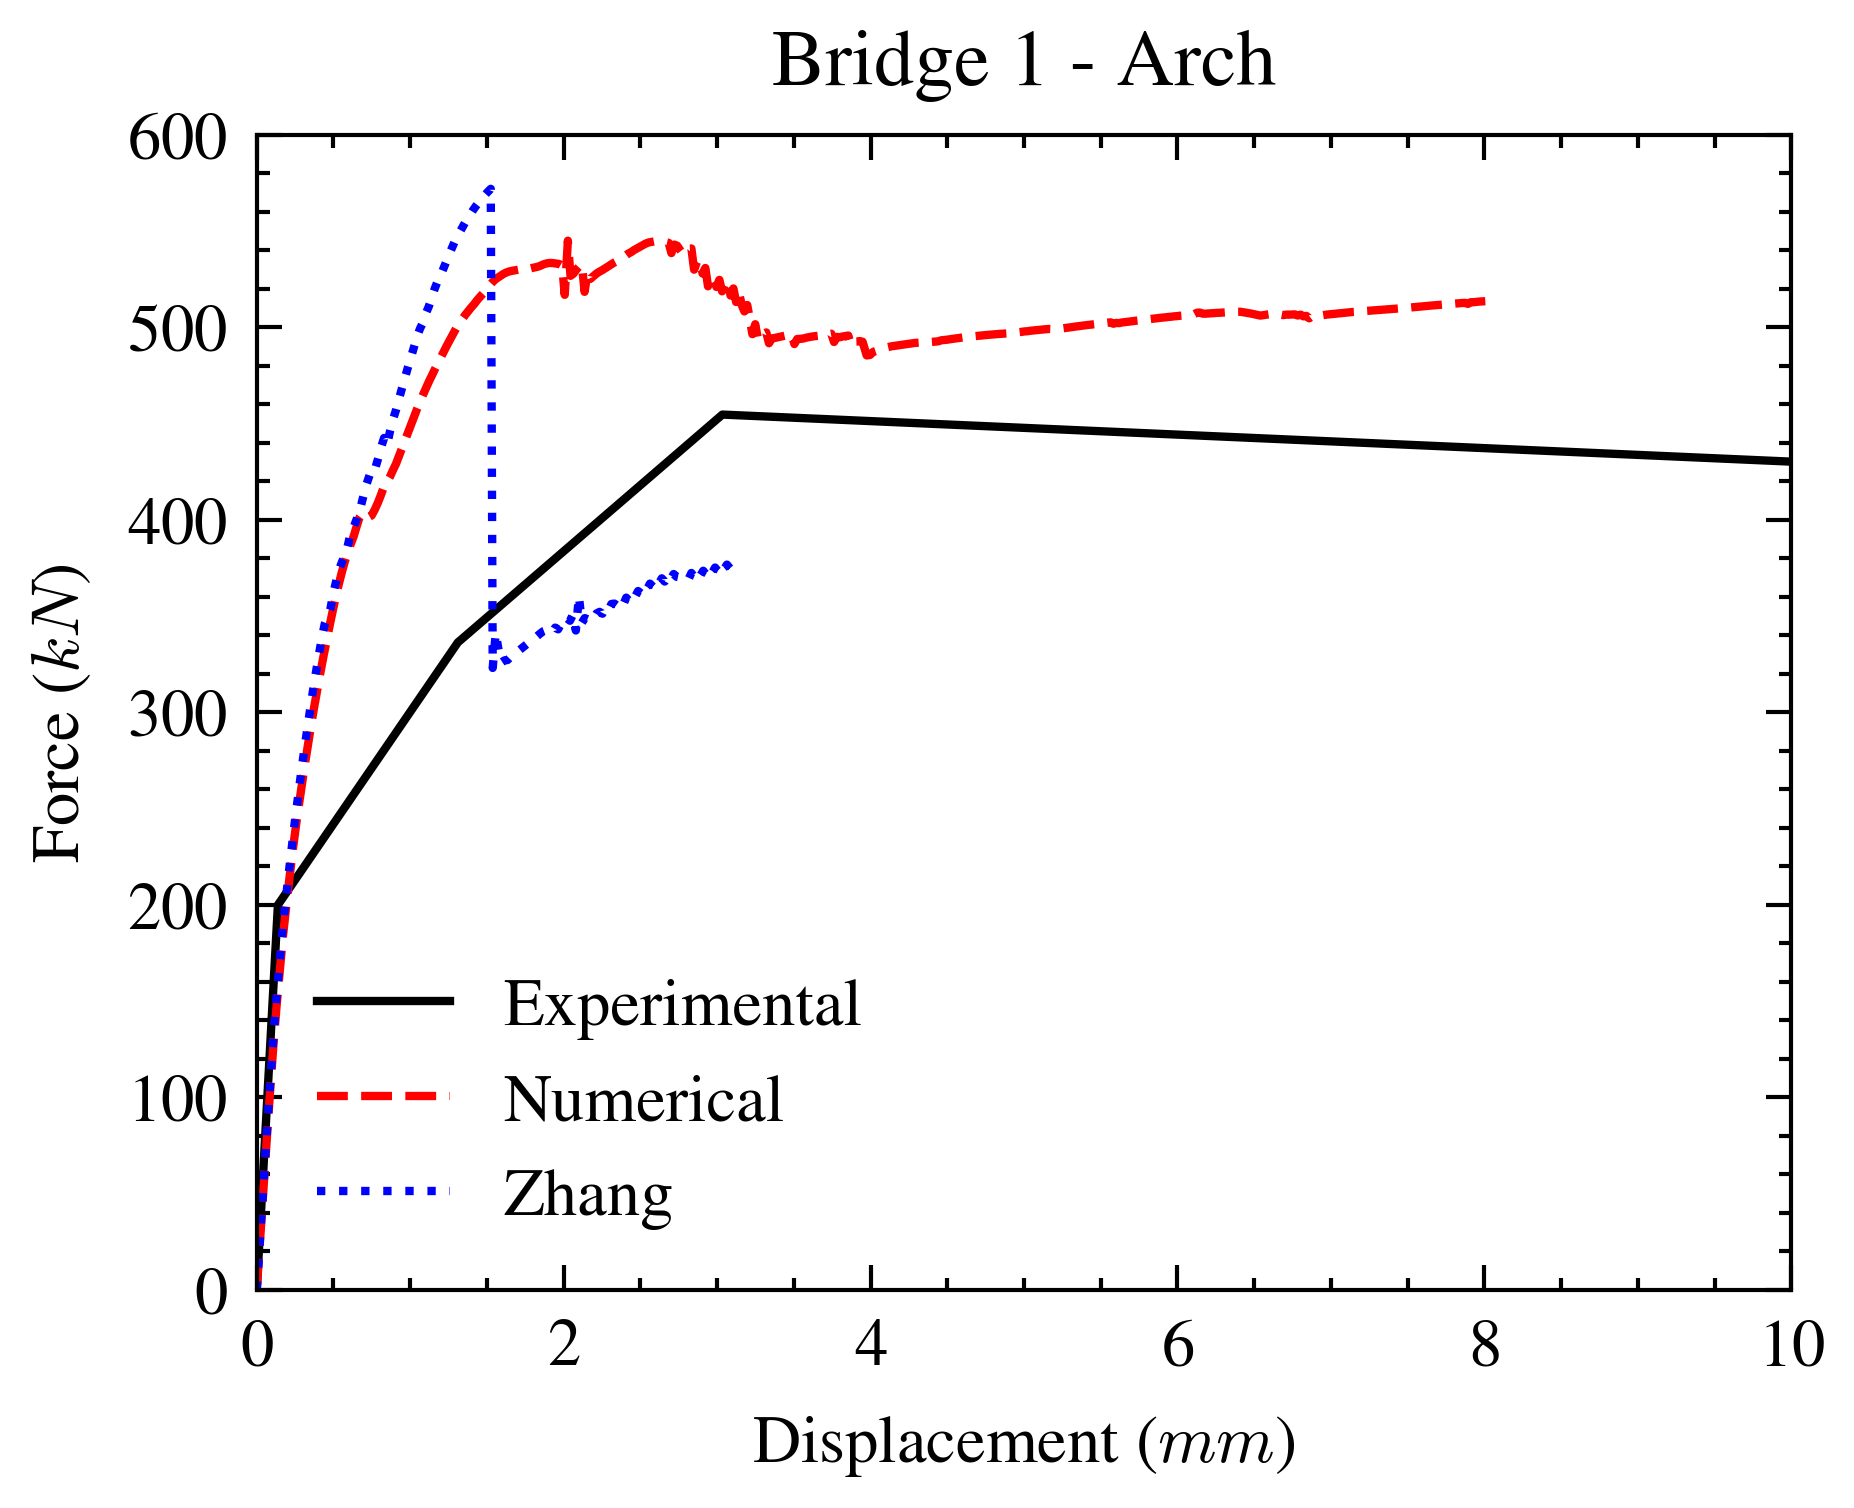

In [ ]:
fig, graph = plt.subplots()

df_bridge = df['Bridge_1_Experimental_Arch']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental')

df_bridge = df['Bridge_1_Numerical_Arch']
#radial_disp = 0.916516*df_bridge['z'] + 0.399998*df_bridge['x']
radial_disp = df_bridge['x']
graph.plot(radial_disp, df_bridge['f'], label='Numerical')

df_bridge = df['Bridge_1_Zhang']
graph.plot(df_bridge['x'], df_bridge['y'], label='Zhang')

graph.set(title ='Bridge 1 - Arch')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([0,10])
graph.set_ylim([0,600])

graph.legend()
#fig.savefig("bridge_1.pdf", bbox_inches = 'tight', pad_inches = 0);

In [ ]:
# bridges = ['Bridge_1_Experimental_PierNorth', 'Bridge_1_Numerical_PierNorth',
#            'Bridge_1_Experimental_PierSouth', 'Bridge_1_Numerical_PierSouth']
# graph_names = ['Experimental-North', 'Numerical-North',
#                'Experimental-South', 'Numerical-South']

# fig, graph = plt.subplots()

# for i,bridge in enumerate(bridges):
#   df_bridge = df[bridge]
#   graph.plot(df_bridge['x'], df_bridge['y'], label=graph_names[i])

# graph.set(title ='Bridge 1 - Piers')
# graph.set(xlabel ='Displacement ($mm$)')
# graph.set(ylabel ='Force ($kN$)')

# graph.set_xlim([-7.5,15])
# graph.set_ylim([0,750])

# graph.legend()
# #fig.savefig("bridge_3.1.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 2

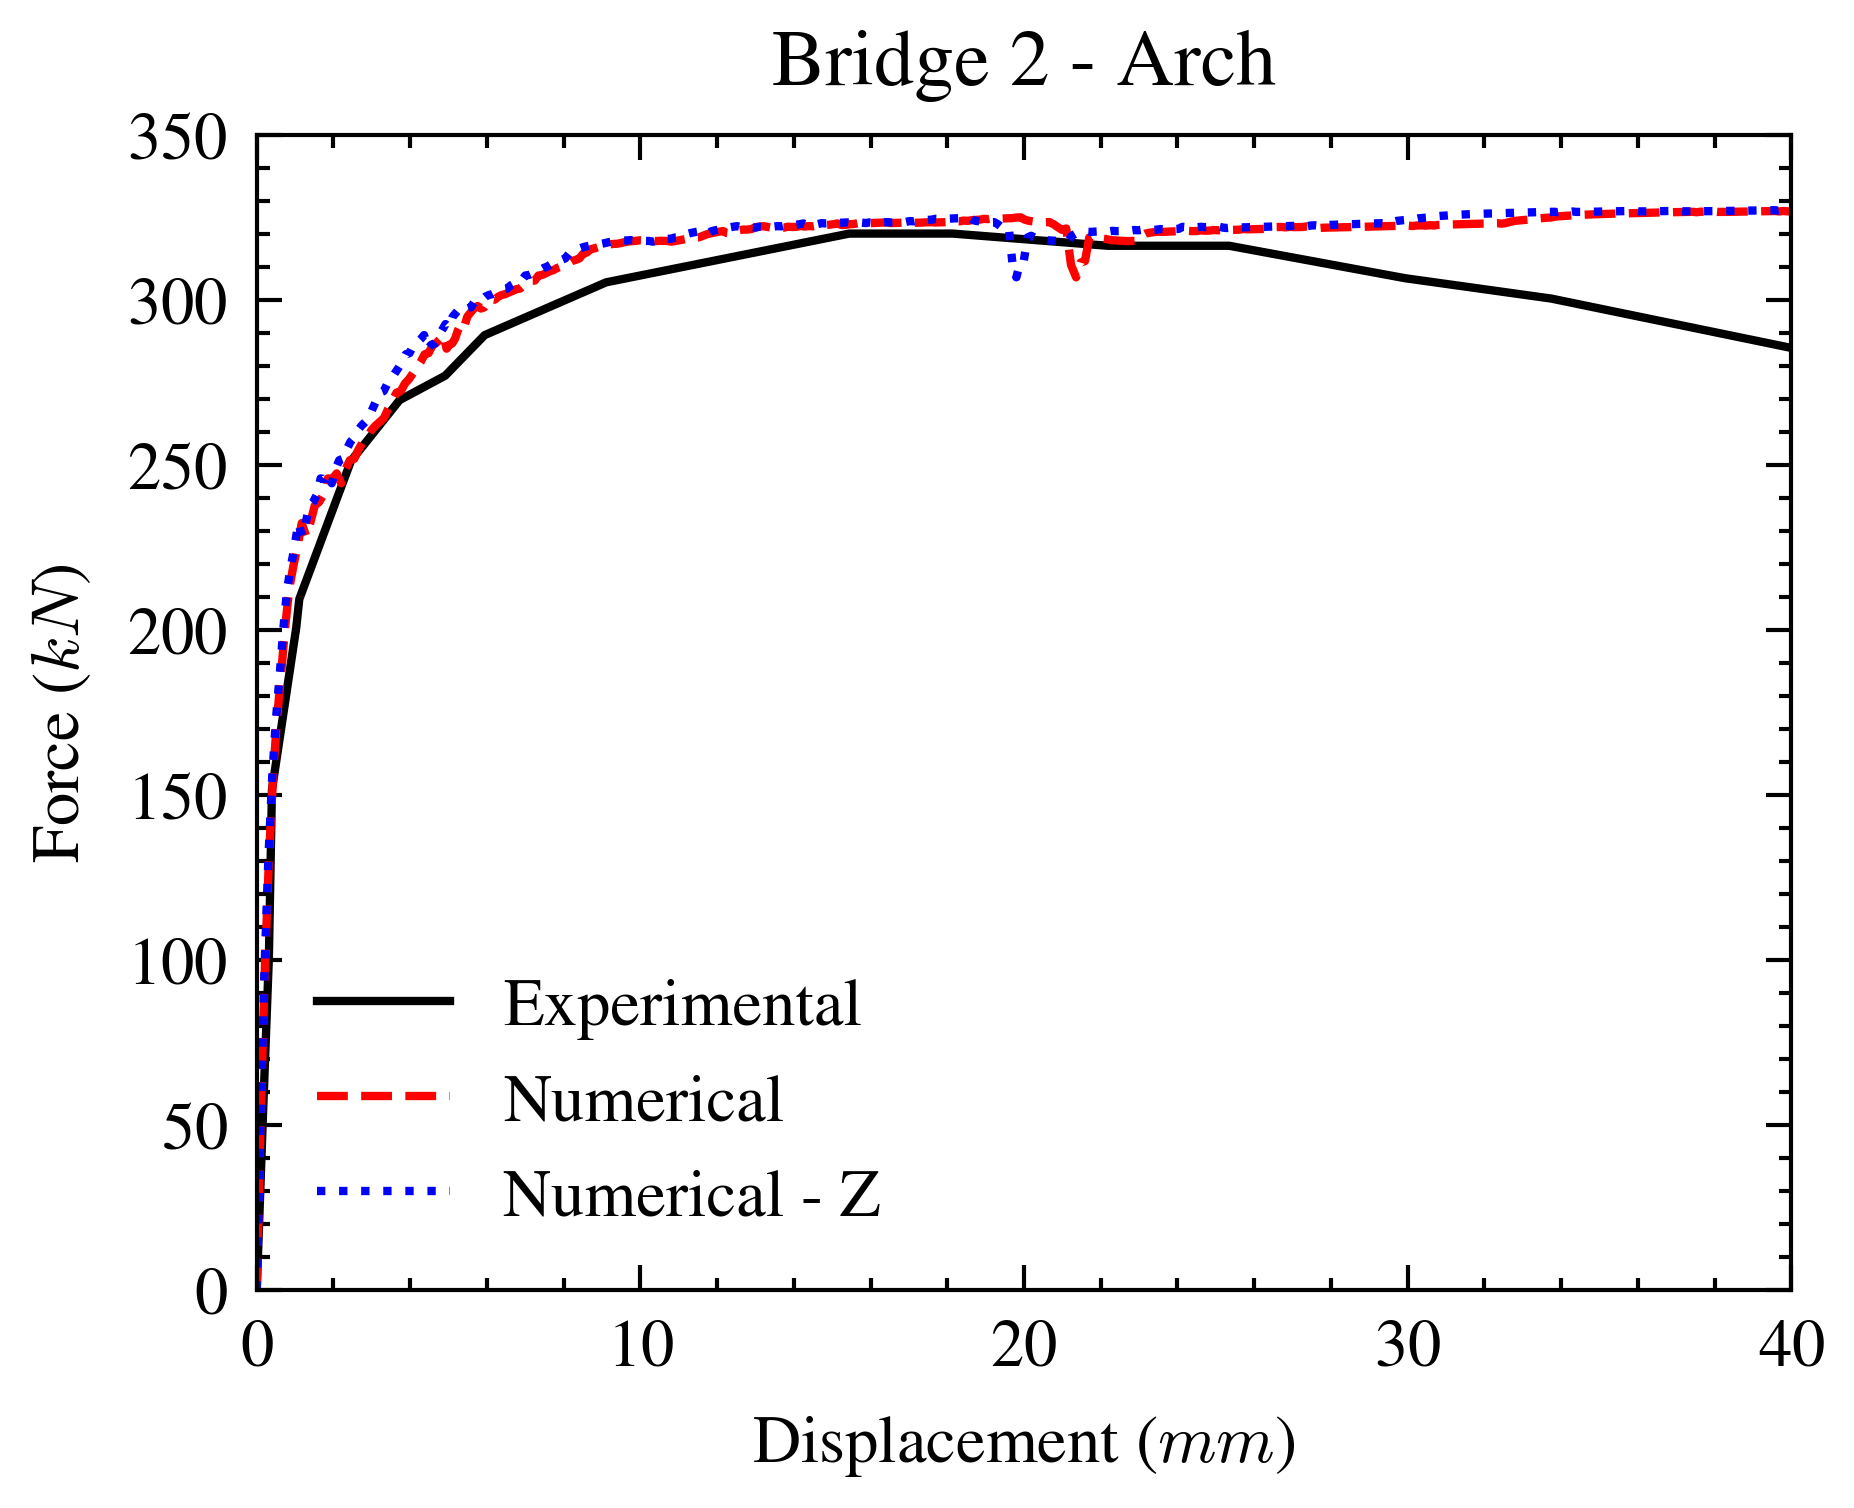

In [ ]:
bridges = {'Bridge_2_Experimental_Arch': 'Experimental',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 2 - Arch', [0,40], [0,350])

df_bridge = df['Bridge_2_Numerical_Arch']
radial_disp = 0.916516*df_bridge['z'] + 0.399998*df_bridge['x']
graph.plot(radial_disp, df_bridge['f'], label='Numerical')
graph.plot(df_bridge['z'], df_bridge['f'], label='Numerical - Z')

# df_bridge = df['Bridge_2_Tubaldi']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Tubaldi et al. (2020)')

# df_bridge = df['Bridge_2_Zizi']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)')



# df_bridge = df['LimitAnalysis_2']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Gilbert et al. (2025)')

graph.legend()

fig.savefig("bridge_2.pdf", bbox_inches = 'tight', pad_inches = 0);

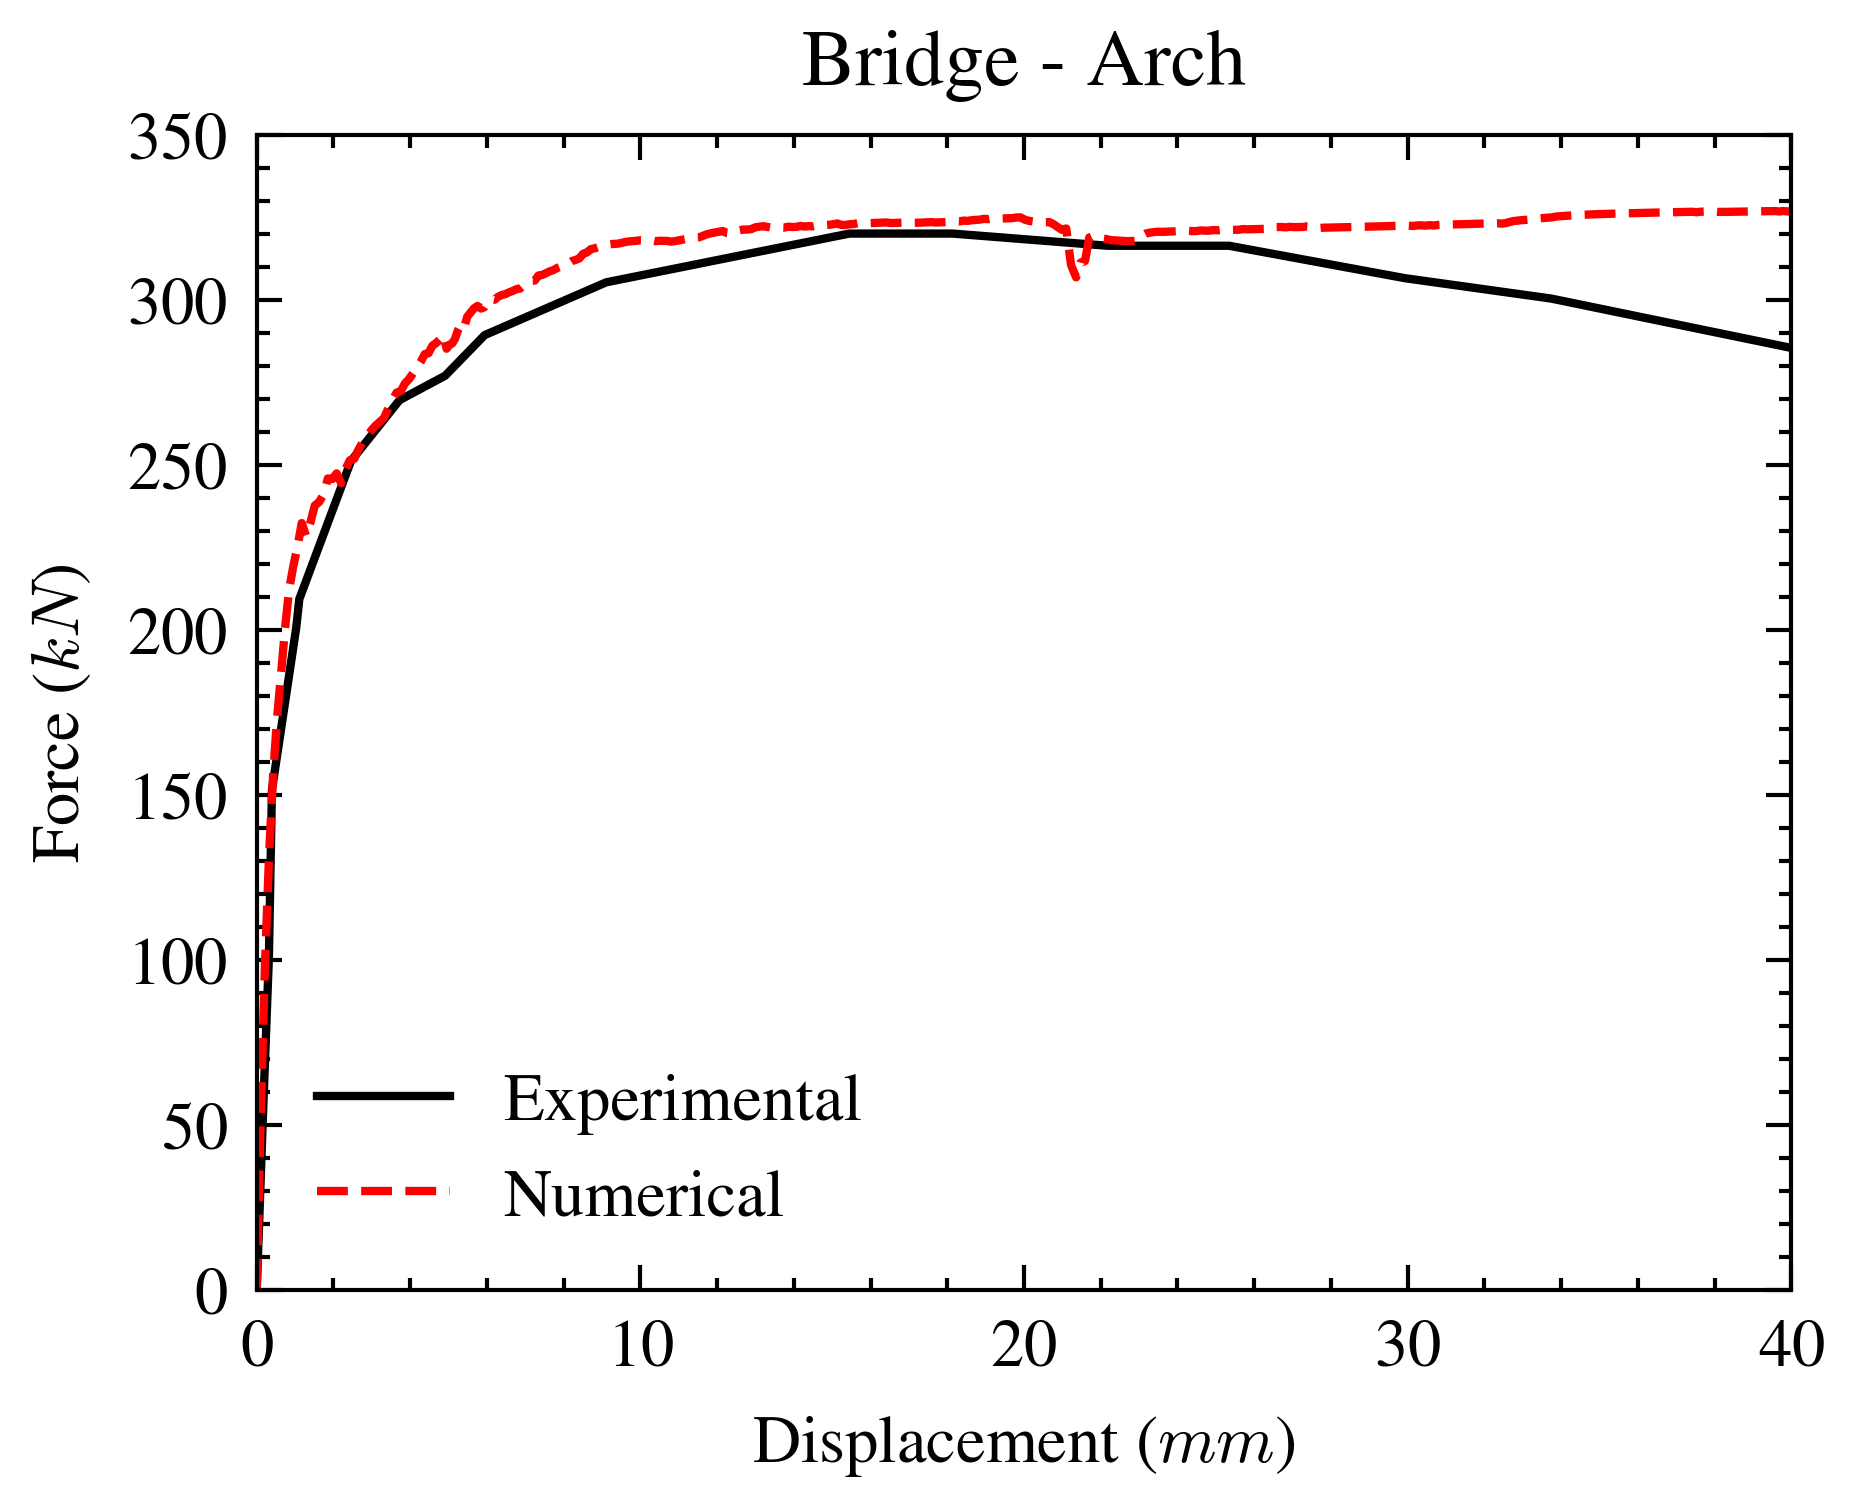

In [ ]:
bridges = {'Bridge_2_Experimental_Arch': 'Experimental',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge - Arch', [0,40], [0,350])

df_bridge = df['Bridge_2_Numerical_Arch']
radial_disp = 0.916516*df_bridge['z'] + 0.399998*df_bridge['x']
graph.plot(radial_disp, df_bridge['f'], label='Numerical')

# df_bridge = df['Bridge_2_Tubaldi']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Tubaldi et al. (2020)')

# df_bridge = df['Bridge_2_Zizi']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)')



# df_bridge = df['LimitAnalysis_2']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Gilbert et al. (2025)')

graph.legend()

fig.savefig("bridge_2.pdf", bbox_inches = 'tight', pad_inches = 0);

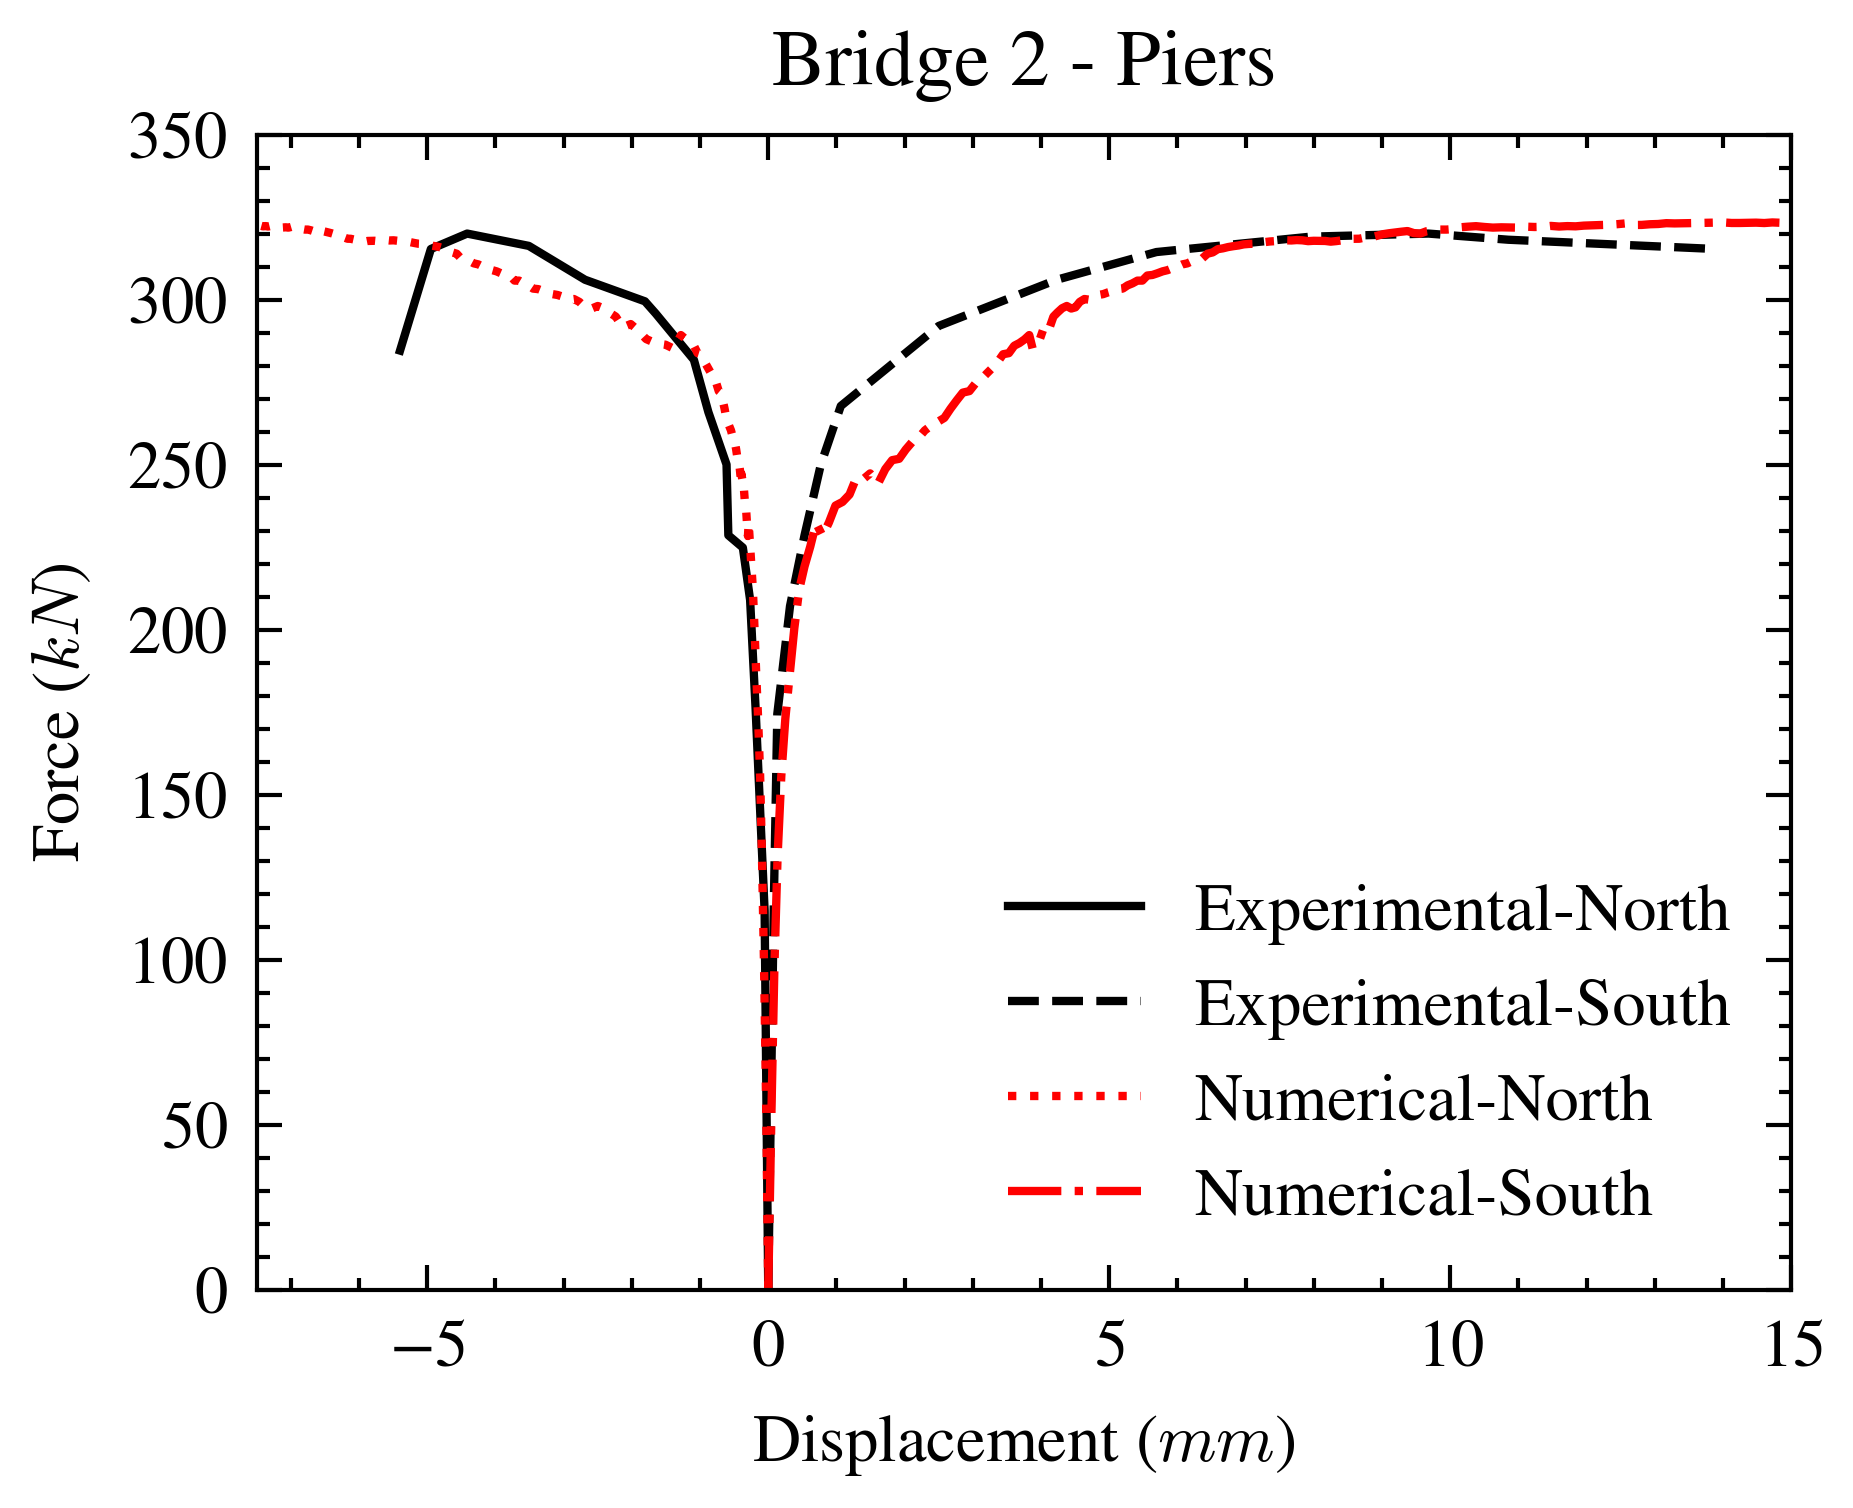

In [ ]:
fig, graph = plt.subplots()

df_bridge = df['Bridge_2_Experimental_PierNorth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental-North', color='k')

df_bridge = df['Bridge_2_Experimental_PierSouth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental-South', color='k')

df_bridge = df['Bridge_2_Numerical_PierNorth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Numerical-North', color='r')

df_bridge = df['Bridge_2_Numerical_PierSouth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Numerical-South', color='r')

# df_bridge = df['Bridge_2_Zizi_PierNorth']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)-North', color='g')

# df_bridge = df['Bridge_2_Zizi_PierSouth']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)-South', color='g')

graph.set(title ='Bridge 2 - Piers')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([-7.5,15])
graph.set_ylim([0,350])

graph.legend()
fig.savefig("bridge_2_pier.pdf", bbox_inches = 'tight', pad_inches = 0);

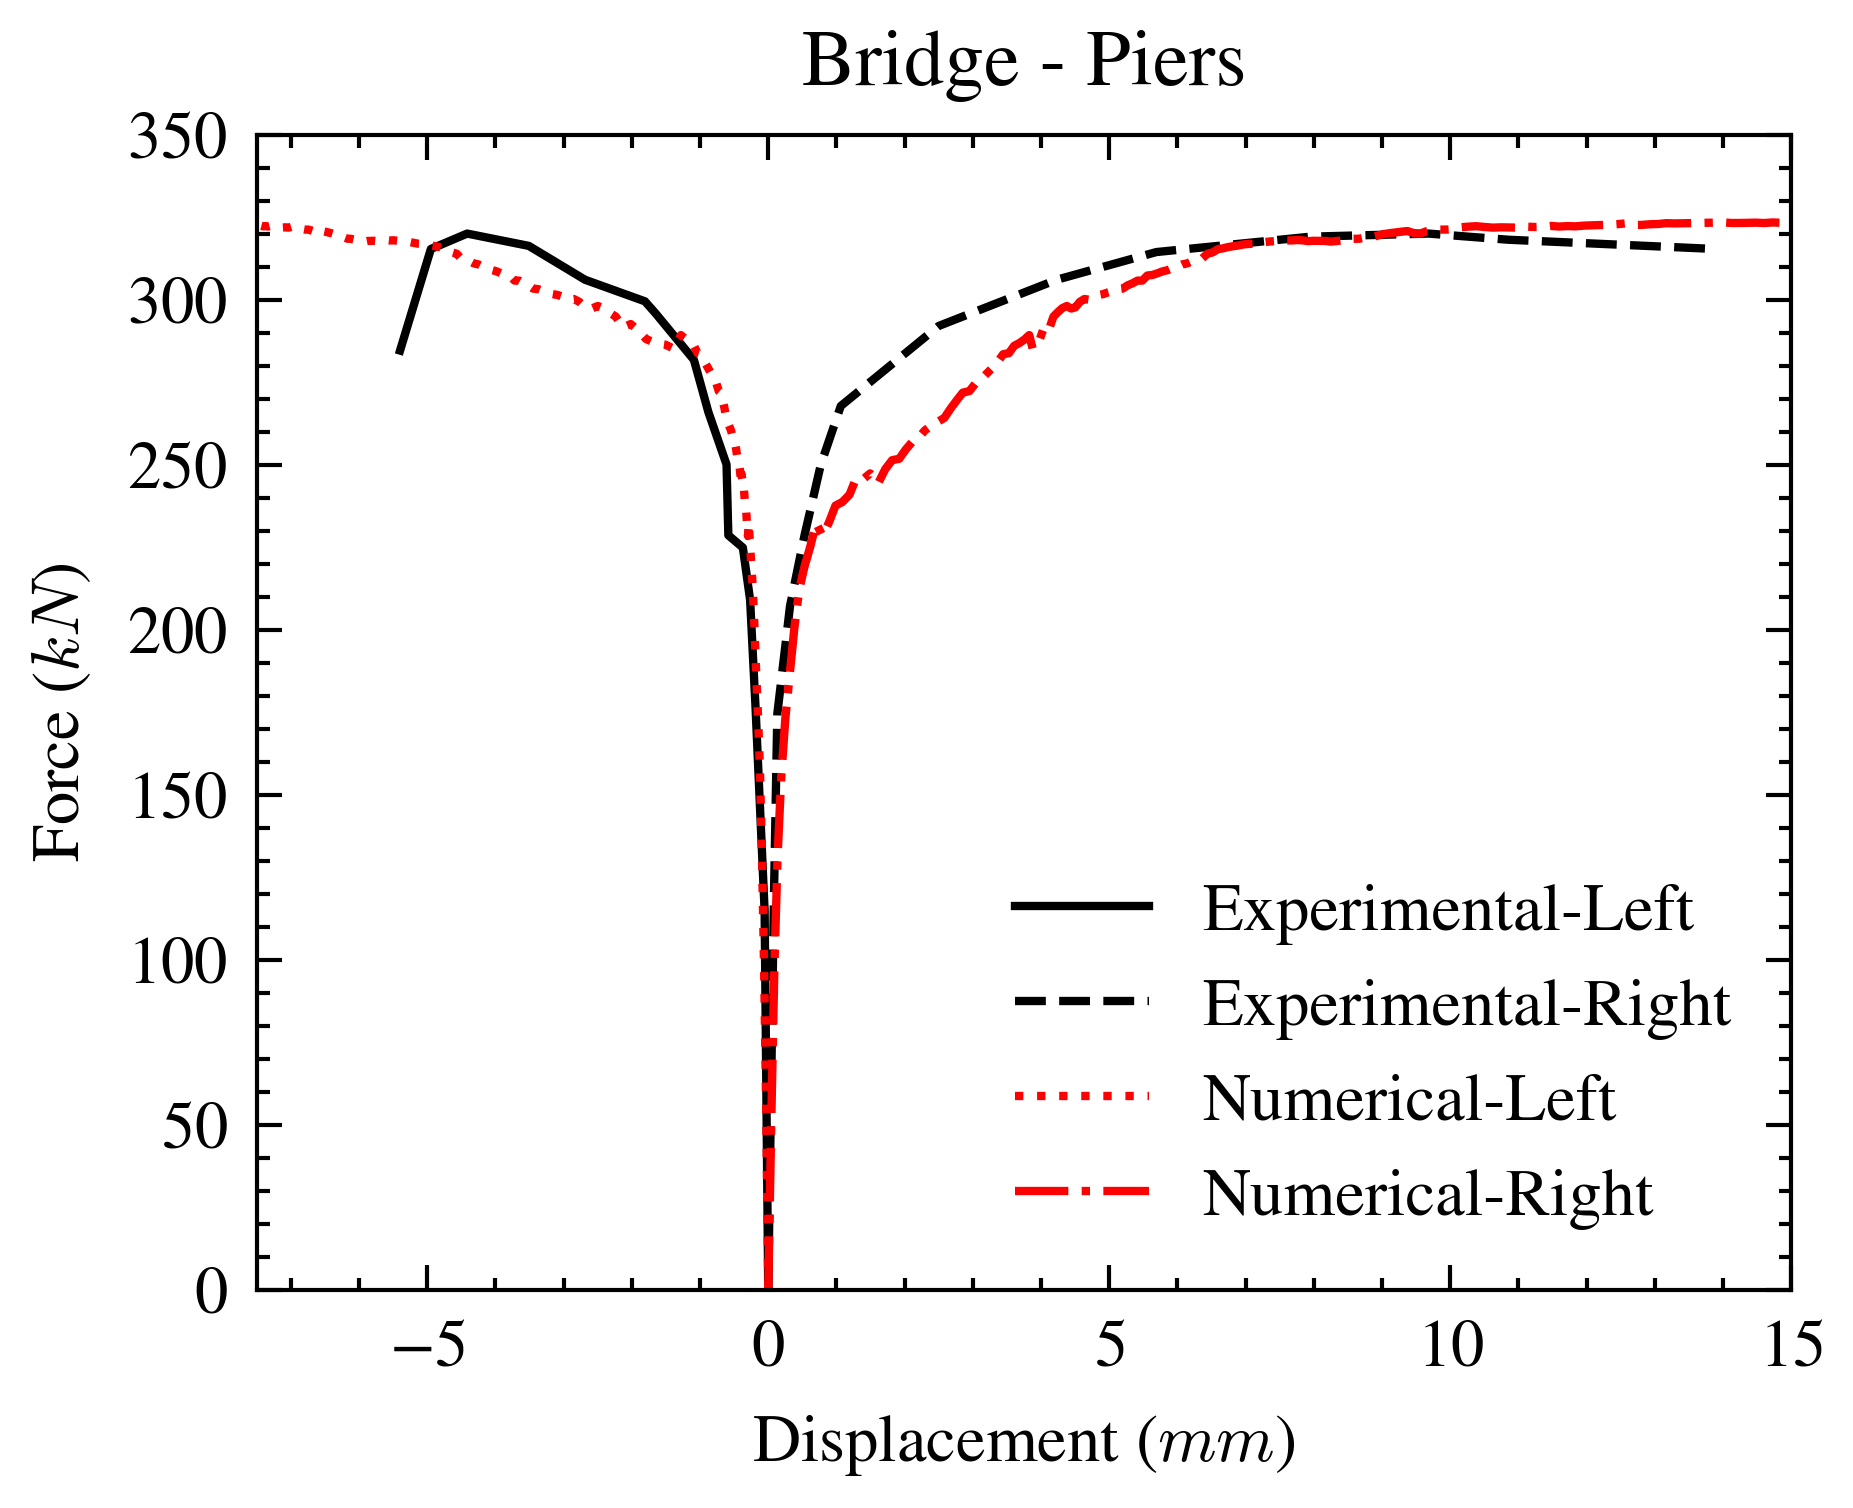

In [ ]:
fig, graph = plt.subplots()

df_bridge = df['Bridge_2_Experimental_PierNorth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental-Left', color='k')

df_bridge = df['Bridge_2_Experimental_PierSouth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Experimental-Right', color='k')

df_bridge = df['Bridge_2_Numerical_PierNorth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Numerical-Left', color='r')

df_bridge = df['Bridge_2_Numerical_PierSouth']
graph.plot(df_bridge['x'], df_bridge['y'], label='Numerical-Right', color='r')

# df_bridge = df['Bridge_2_Zizi_PierNorth']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)-North', color='g')

# df_bridge = df['Bridge_2_Zizi_PierSouth']
# graph.plot(df_bridge['x'], df_bridge['y'], label='Zizi et al. (2024)-South', color='g')

graph.set(title ='Bridge - Piers')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$)')

graph.set_xlim([-7.5,15])
graph.set_ylim([0,350])

graph.legend()
fig.savefig("bridge_2_pier.pdf", bbox_inches = 'tight', pad_inches = 0);

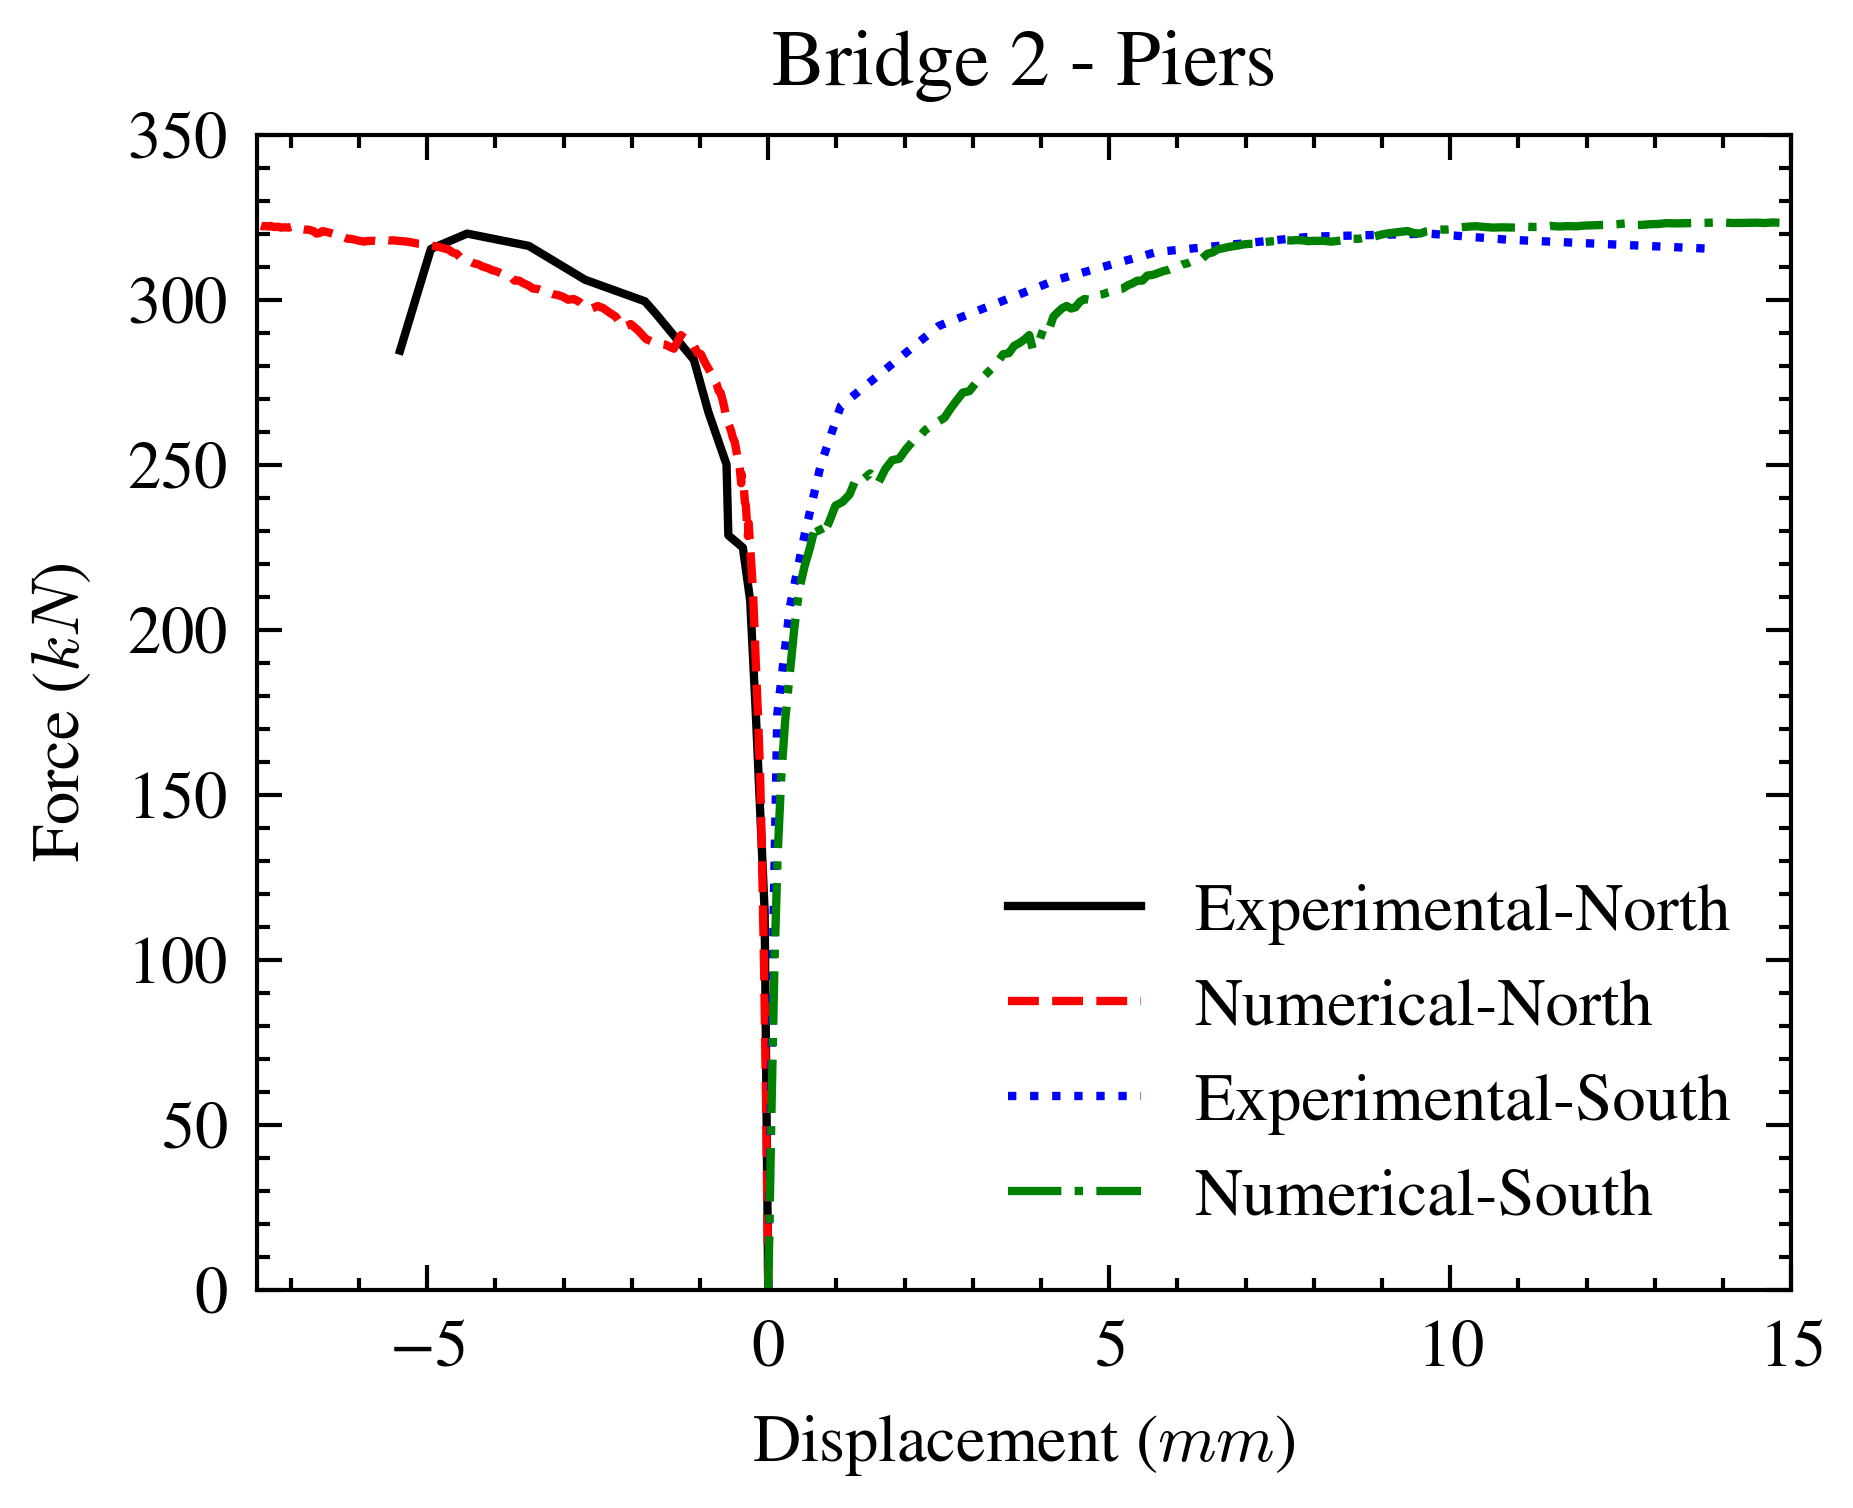

In [ ]:
bridges = {
    'Bridge_2_Experimental_PierNorth': 'Experimental-North',
    'Bridge_2_Numerical_PierNorth': 'Numerical-North',
    'Bridge_2_Experimental_PierSouth': 'Experimental-South',
    'Bridge_2_Numerical_PierSouth': 'Numerical-South',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 2 - Piers', [-7.5,15], [0,350])

graph.legend()
#fig.savefig("bridge_2.pdf", bbox_inches = 'tight', pad_inches = 0);

## Bridge 3

In [ ]:
ft = 0.2 #MPa
gf = 0.025 * (2 * ft)**0.7
gf

0.013163822043342375

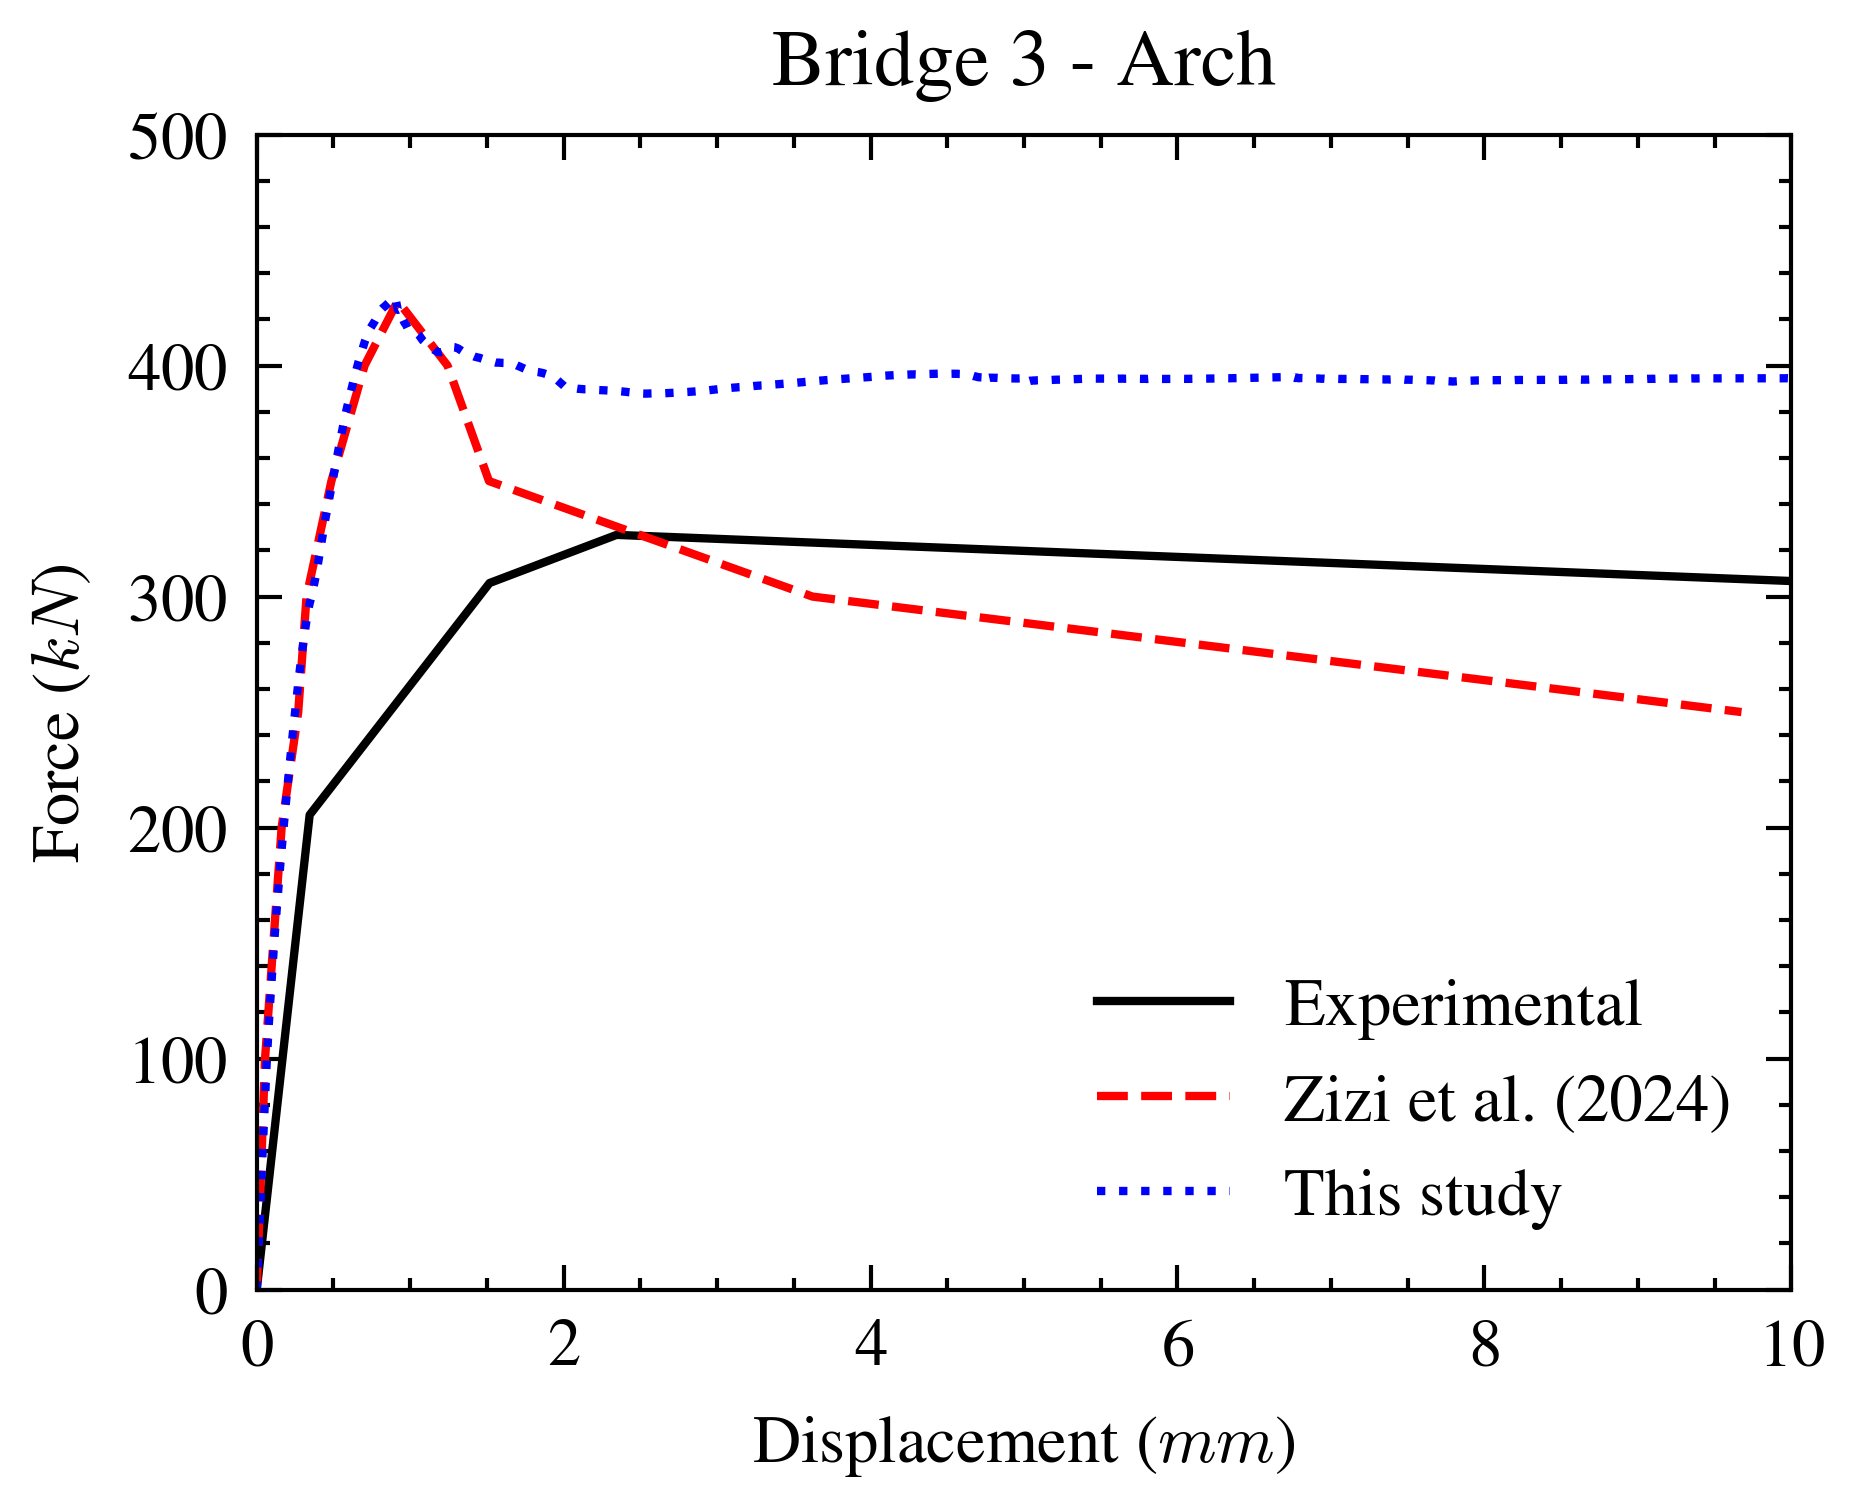

In [ ]:
bridges = {'Bridge_3_Experimental_Arch': 'Experimental',
           'Bridge_3_Numerical_Zizi': 'Zizi et al. (2024)',
           'Bridge_3_Backfill': 'This study',
           }

fig, graph = plt.subplots()

plot(graph, bridges, 'Bridge 3 - Arch', [0,10], [0,500])

# graph.plot([0,40], [234,234], '--' ,label="Heyman's hypotheses")

#fig.savefig("bridge_3.pdf", bbox_inches = 'tight', pad_inches = 0);

# Arch extrados / Fill surface

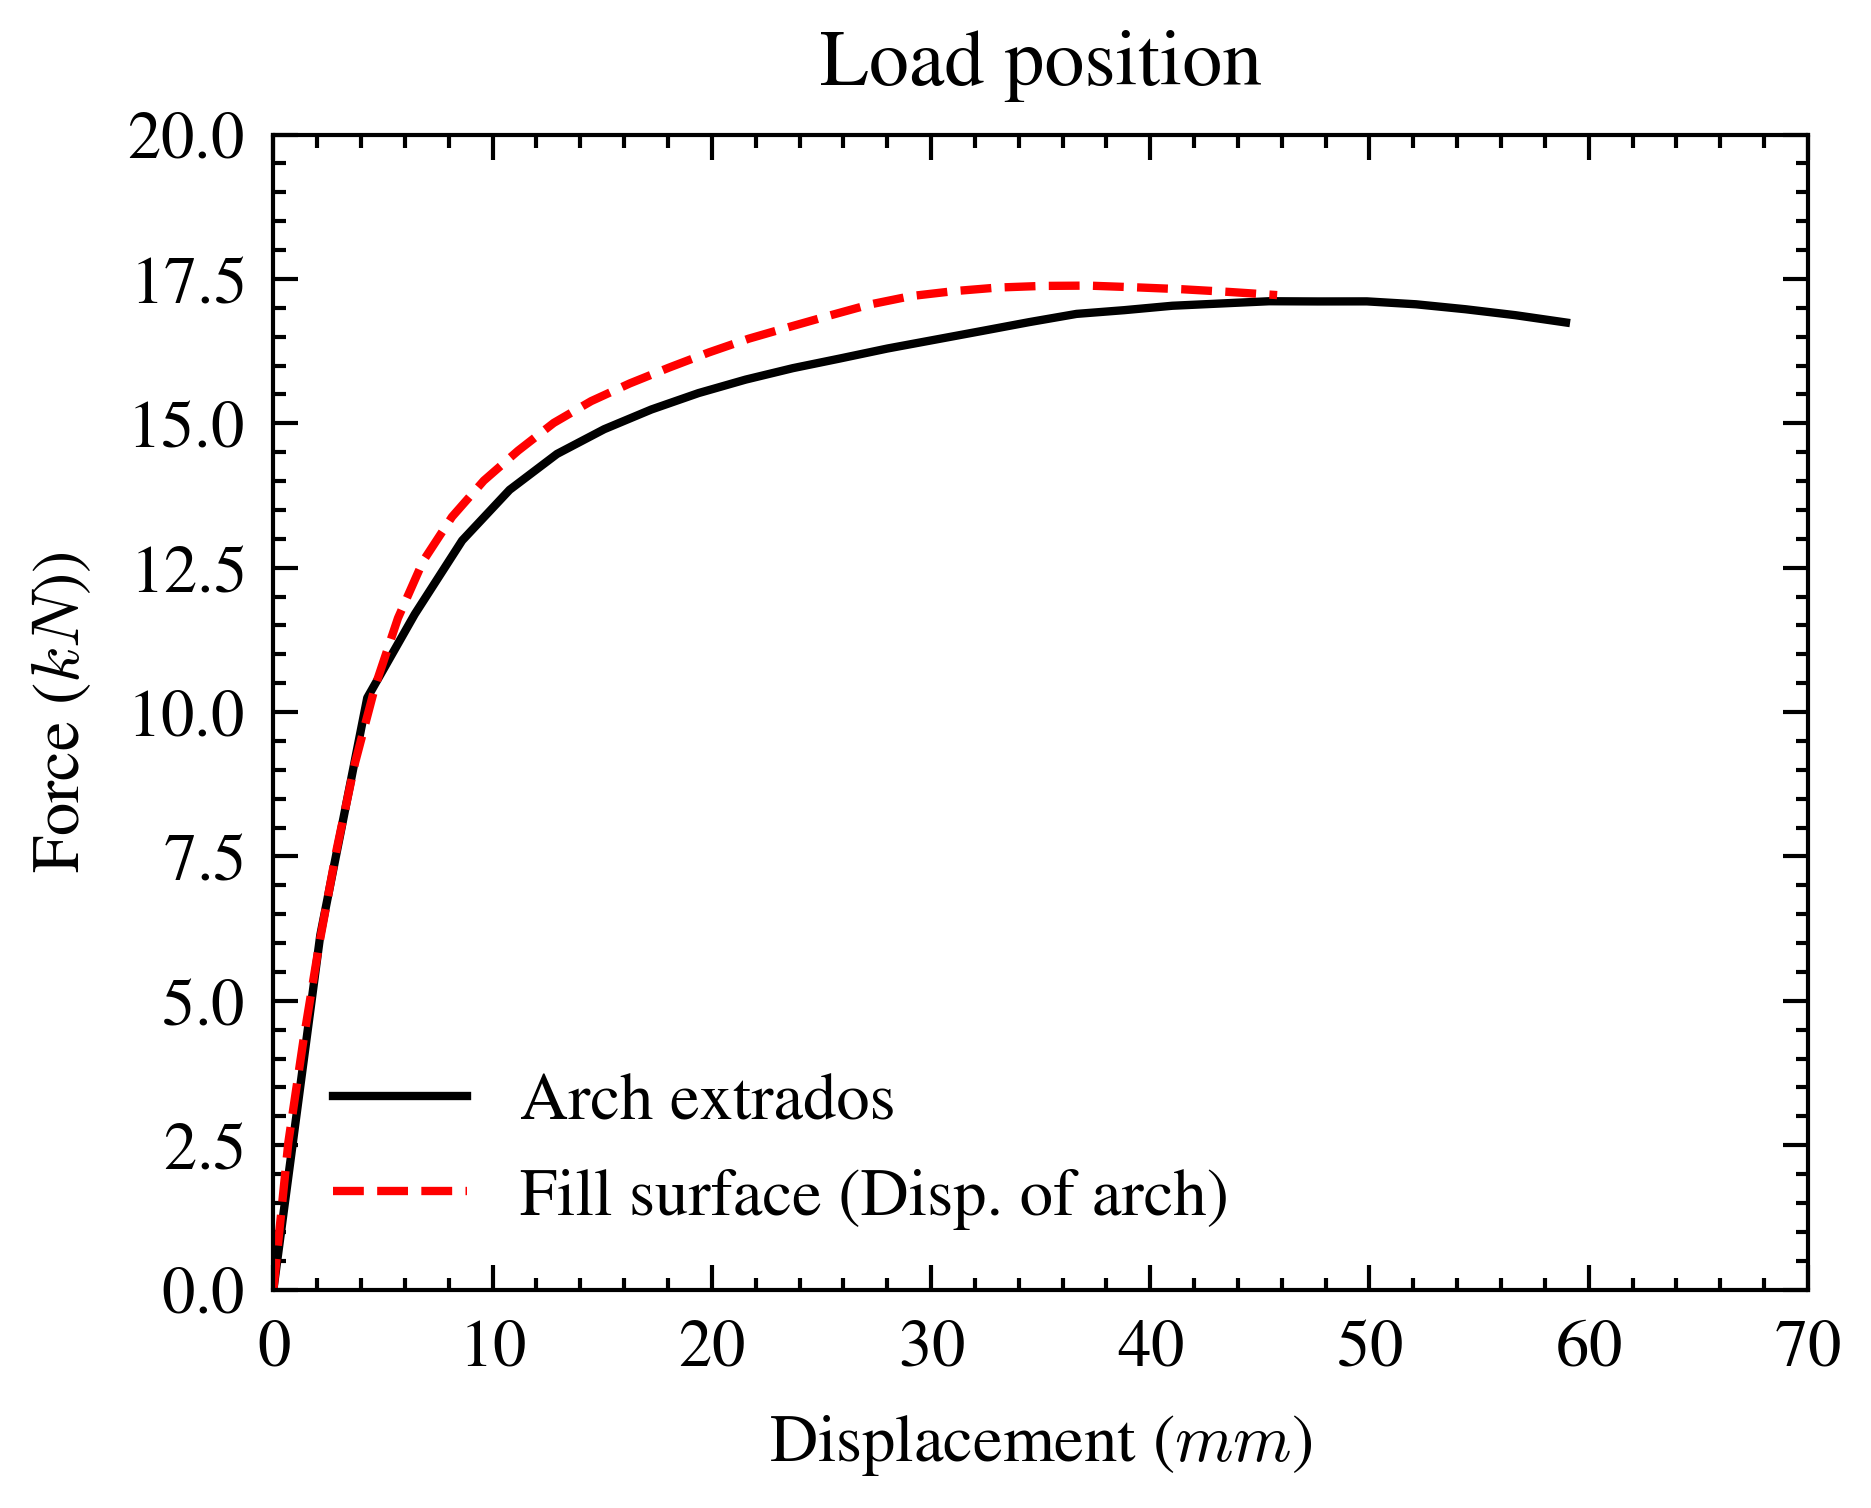

In [ ]:
bridges = ['arch_extrados',
           #'fill_surface',
           'fill_surface_disp_arch']
graph_names = ['Arch extrados',
               #'Fill surface',
               'Fill surface (Disp. of arch)']

fig, graph = plt.subplots()

for i,bridge in enumerate(bridges):
  df_bridge = df[bridge]
  graph.plot(df_bridge['x'], df_bridge['y'], label=graph_names[i])

graph.set(title ='Load position')
graph.set(xlabel ='Displacement ($mm$)')
graph.set(ylabel ='Force ($kN$))')

graph.set_xlim([0,70])
graph.set_ylim([0,20])

graph.legend()
# fig.savefig("bridge_3.1.pdf", bbox_inches = 'tight', pad_inches = 0);

# Constituive models

In [ ]:
def add_line(ax, x, y):
    ax.plot(x, y, 'k')

    # Arrow in the middle of the first line
    ax.annotate("",
                xy=((x[0]+x[1])/2, (y[0]+y[1])/2),       # Arrow tip
                xytext=(x[0], y[0]),         # Arrow tail
                arrowprops=dict(arrowstyle="->", color='k', mutation_scale=20, linewidth=2))

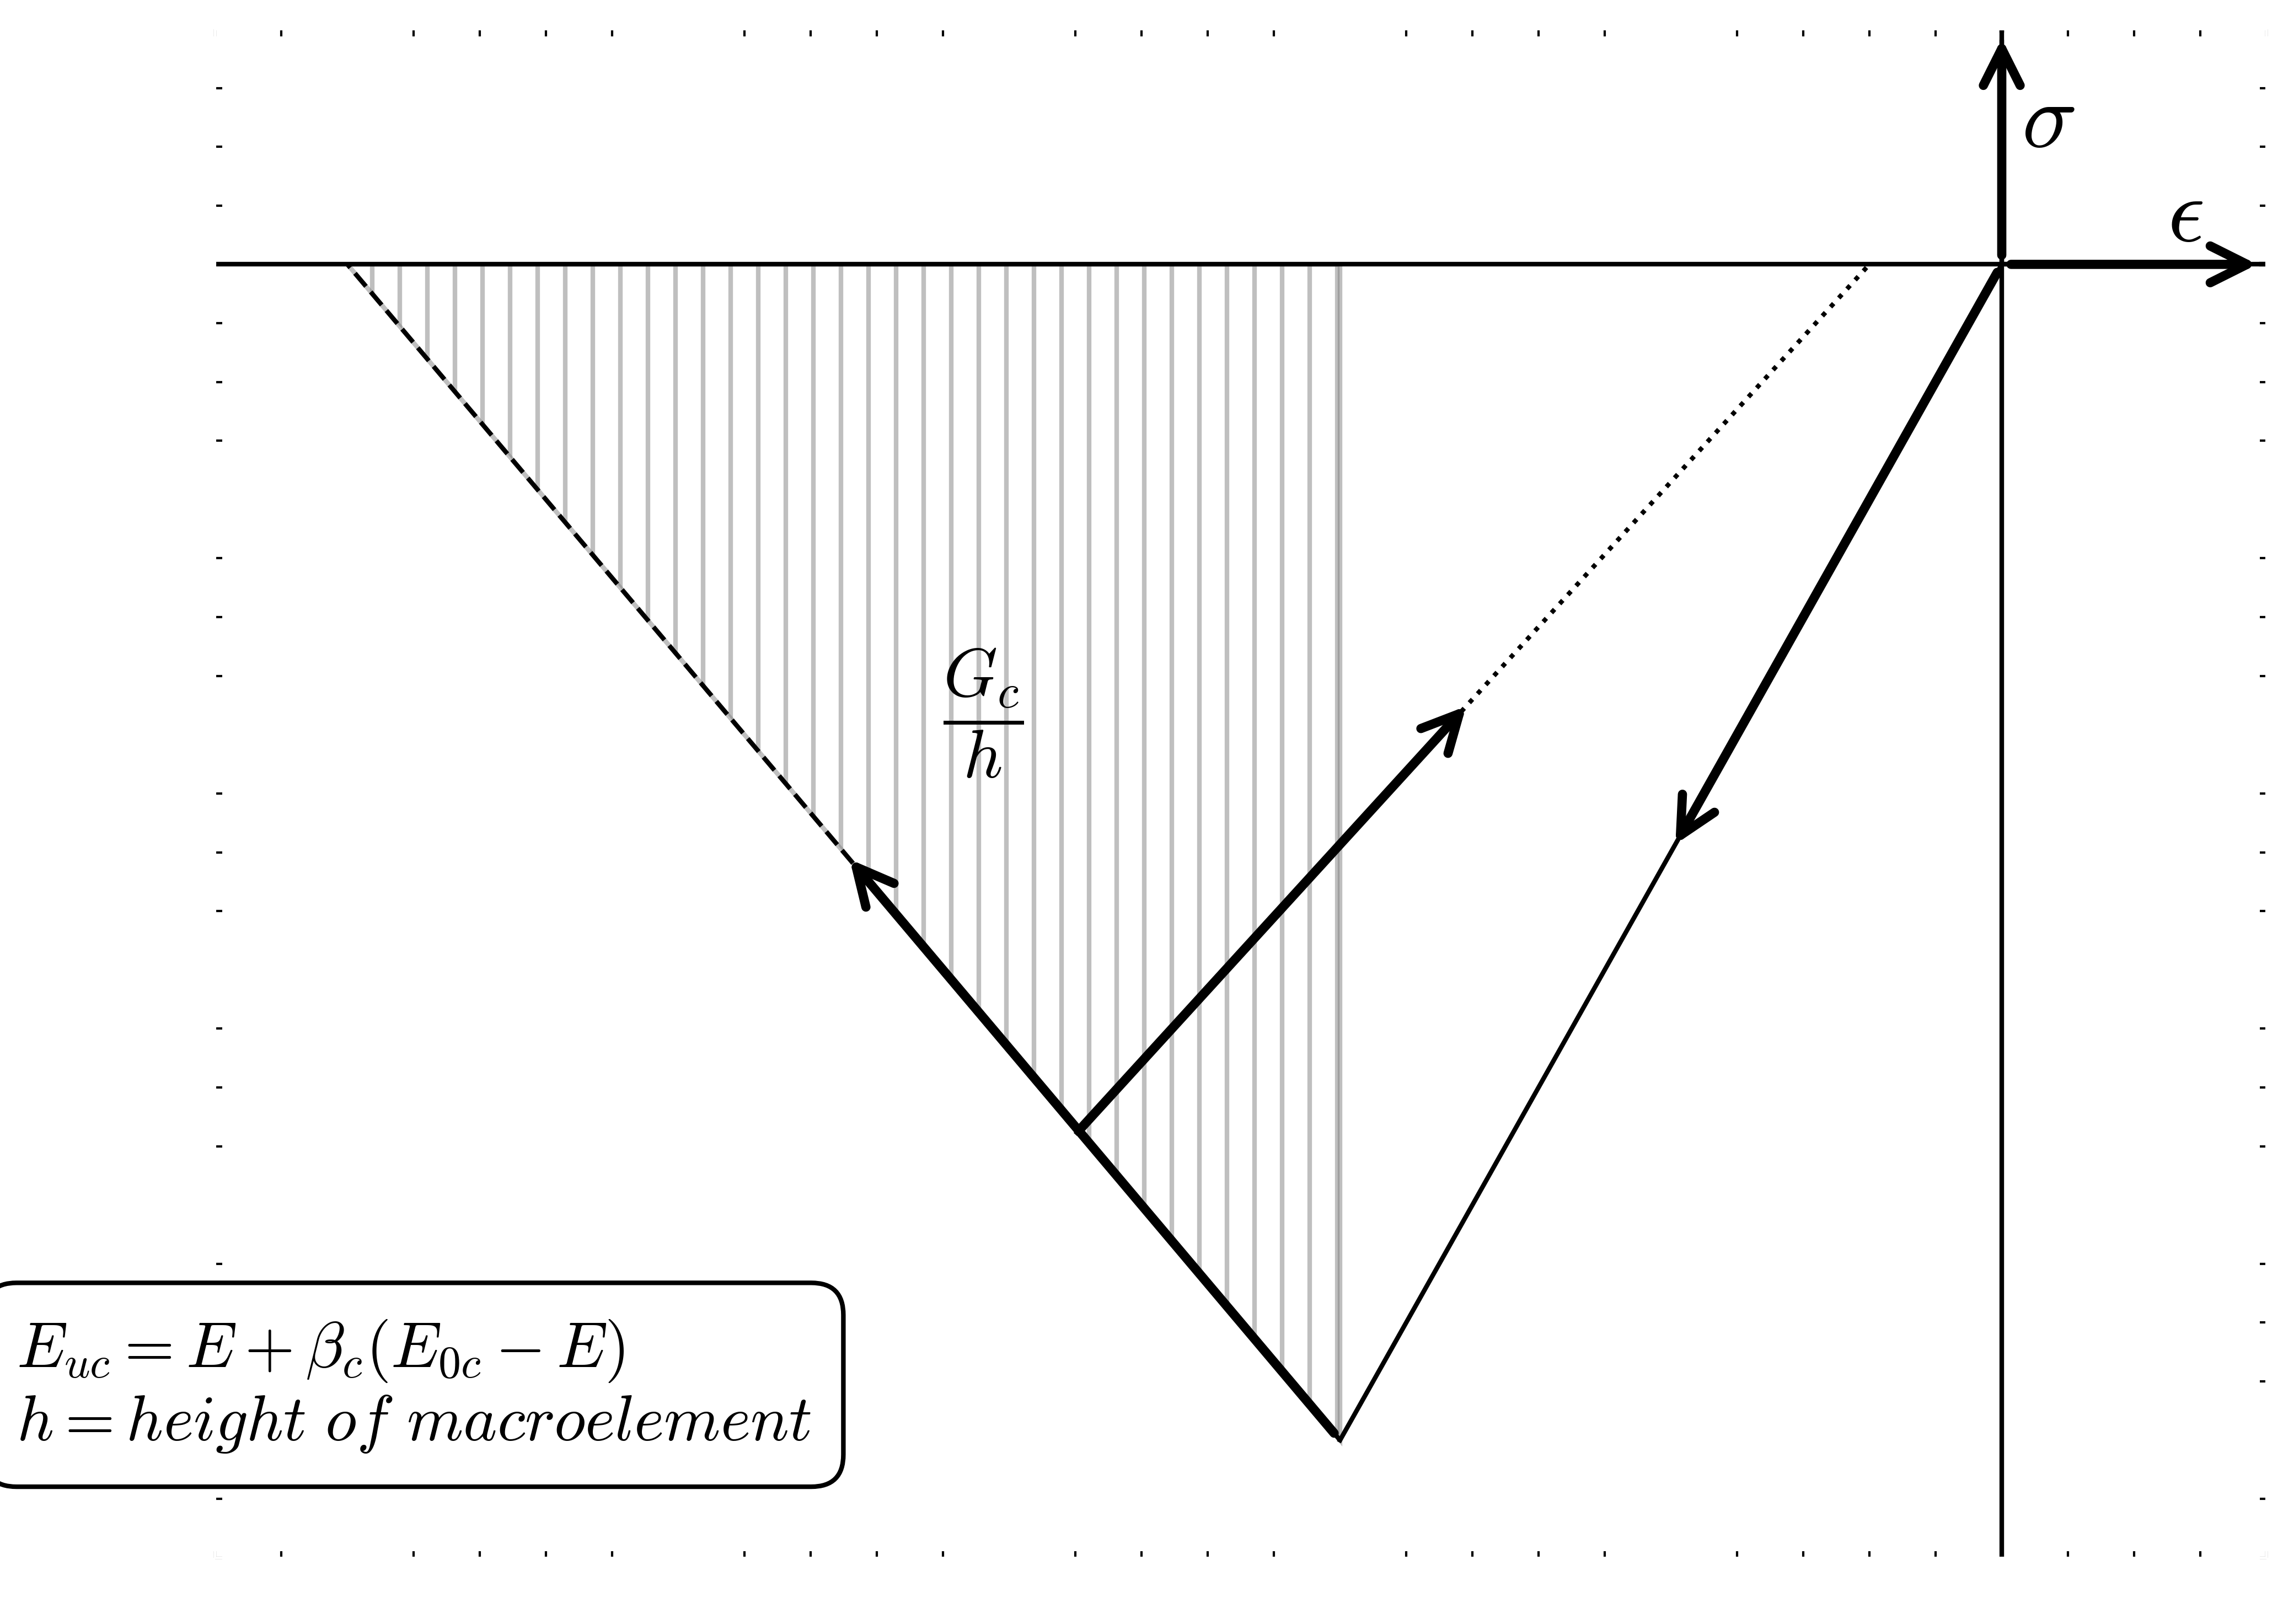

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))

add_line(ax, [0,-1], [0,-1])
add_line(ax, [-1,-2.5], [-1,0])
add_line(ax, [-1.4,-0.2], [-.74,0])

# Triangular shaded region
epsilon = np.array([-1, -1, -2.5])
sigma = np.array([0, -1, 0])
ax.fill(epsilon, sigma, facecolor='white', edgecolor='gray', alpha=0.5, hatch='||')

# Add Gc/h text (inside the hatched region)
ax.text(-1.6, -0.4, r'$\dfrac{G_c}{h}$', fontsize=15)

# Equation box
ax.text(-3, -1,
        r'$E_{uc} = E + \beta_c (E_{0c} - E)$' '\n' r'$h = height \ of \ macroelement$',
        fontsize=14, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


# Annotations and labels
ax.axvline(x=0, color='k', lw=1)
ax.axhline(y=0, color='k', lw=1)

# Set custom y-axis ticks
add_line(ax, [0,0], [0,.4])
ax.text(0.03, 0.1,
        r'$\sigma$',
        fontsize=20
        )

add_line(ax, [0,.8], [0,0])
ax.text(0.25, 0.02,
        r'$\epsilon$',
        fontsize=20
        )

ax.set_xlim(-2.7, 0.4)
ax.set_ylim(-1.1, 0.2)

# Style
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

/tmp/ipykernel_1109/3432237889.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


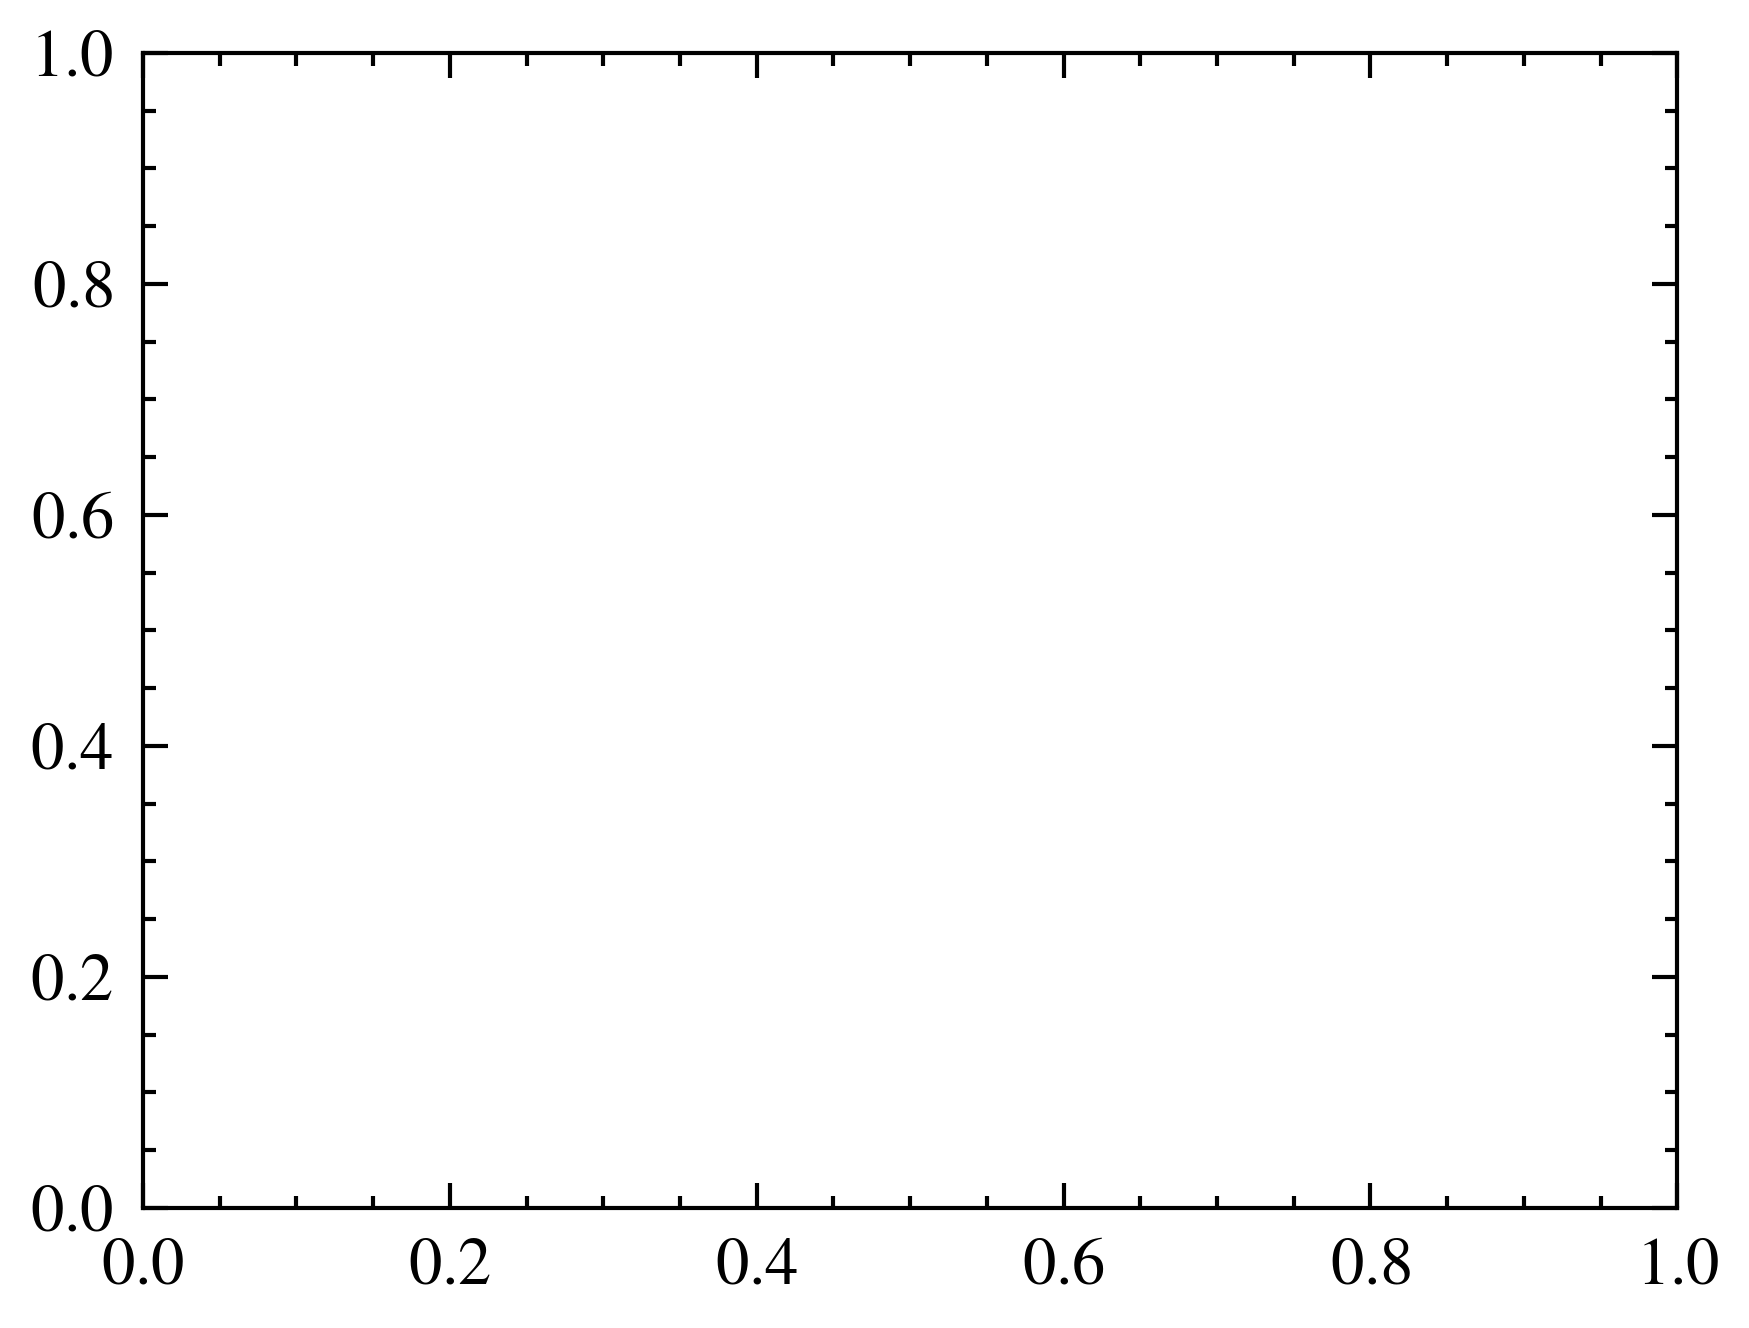

In [ ]:
# Parameters
E = 200  # Initial modulus
E0c = 250  # Initial unloading modulus
beta_c = 0.5  # Factor for modulus reduction
G_c = 100  # Fracture energy
h = 10  # height of macroelement
sigma_yc = -50  # Yield stress
eps_yc = sigma_yc / E  # Yield strain

# Strain range
eps = np.linspace(-2 * eps_yc, 0 * eps_yc, 200)

# Stress-strain relationship (triangular shape)
sigma = np.piecewise(eps,
                     [eps <= 0, eps > 0],
                     [lambda e: sigma_yc * (1 + e / eps_yc),  # Left branch (negative)
                      lambda e: sigma_yc * (1 - e / eps_yc)])  # Right branch (positive)

# Effective unloading modulus
E_uc = E + beta_c * (E0c - E)

# ax.plot(eps, sigma, 'w', lw=2)  # Main triangular shape

# Highlight unloading modulus slope
eps_line = np.array([0, eps_yc])
sigma_line = np.array([0, E_uc * eps_yc])
ax.plot(eps_line, sigma_line, 'w', label=r'$E_{uc}$')

# Annotations and labels
ax.axvline(x=0, color='w', lw=1)
ax.axhline(y=0, color='w', lw=1)

ax.text(0.5 * eps_yc, sigma_yc * 0.5, r'$E$', color='white')
ax.text(eps_yc * 0.8, sigma_yc * 0.4, r'$E_{uc}$', color='white')
ax.text(eps_yc * 1.1, sigma_yc * 0.1, r'$\frac{G_c}{h}$', color='white')

# Box with equation
ax.text(-1.8 * eps_yc, -0.8 * sigma_yc,
        r'$E_{uc} = E + \beta_c (E_{0c} - E)$' '\n' r'$h = height \ of \ macroelement$',
        color='white', fontsize=10, bbox=dict(facecolor='black', edgecolor='white', boxstyle='round,pad=0.5'))

# Axis labels
ax.set_xlabel(r'$\varepsilon$', color='white')
ax.set_ylabel(r'$\sigma$', color='white')

# Axis labels with arrows
# ax.annotate(r'$\varepsilon$', xy=(1.1 * eps_yc, 0), xytext=(1.2 * eps_yc, 0),
#             arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=14)
# ax.annotate(r'$\sigma$', xy=(0, 1.1 * sigma_yc), xytext=(0, 1.2 * sigma_yc),
#             arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=14)

# Style
ax.set_facecolor('black')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

plt.legend()
plt.show()


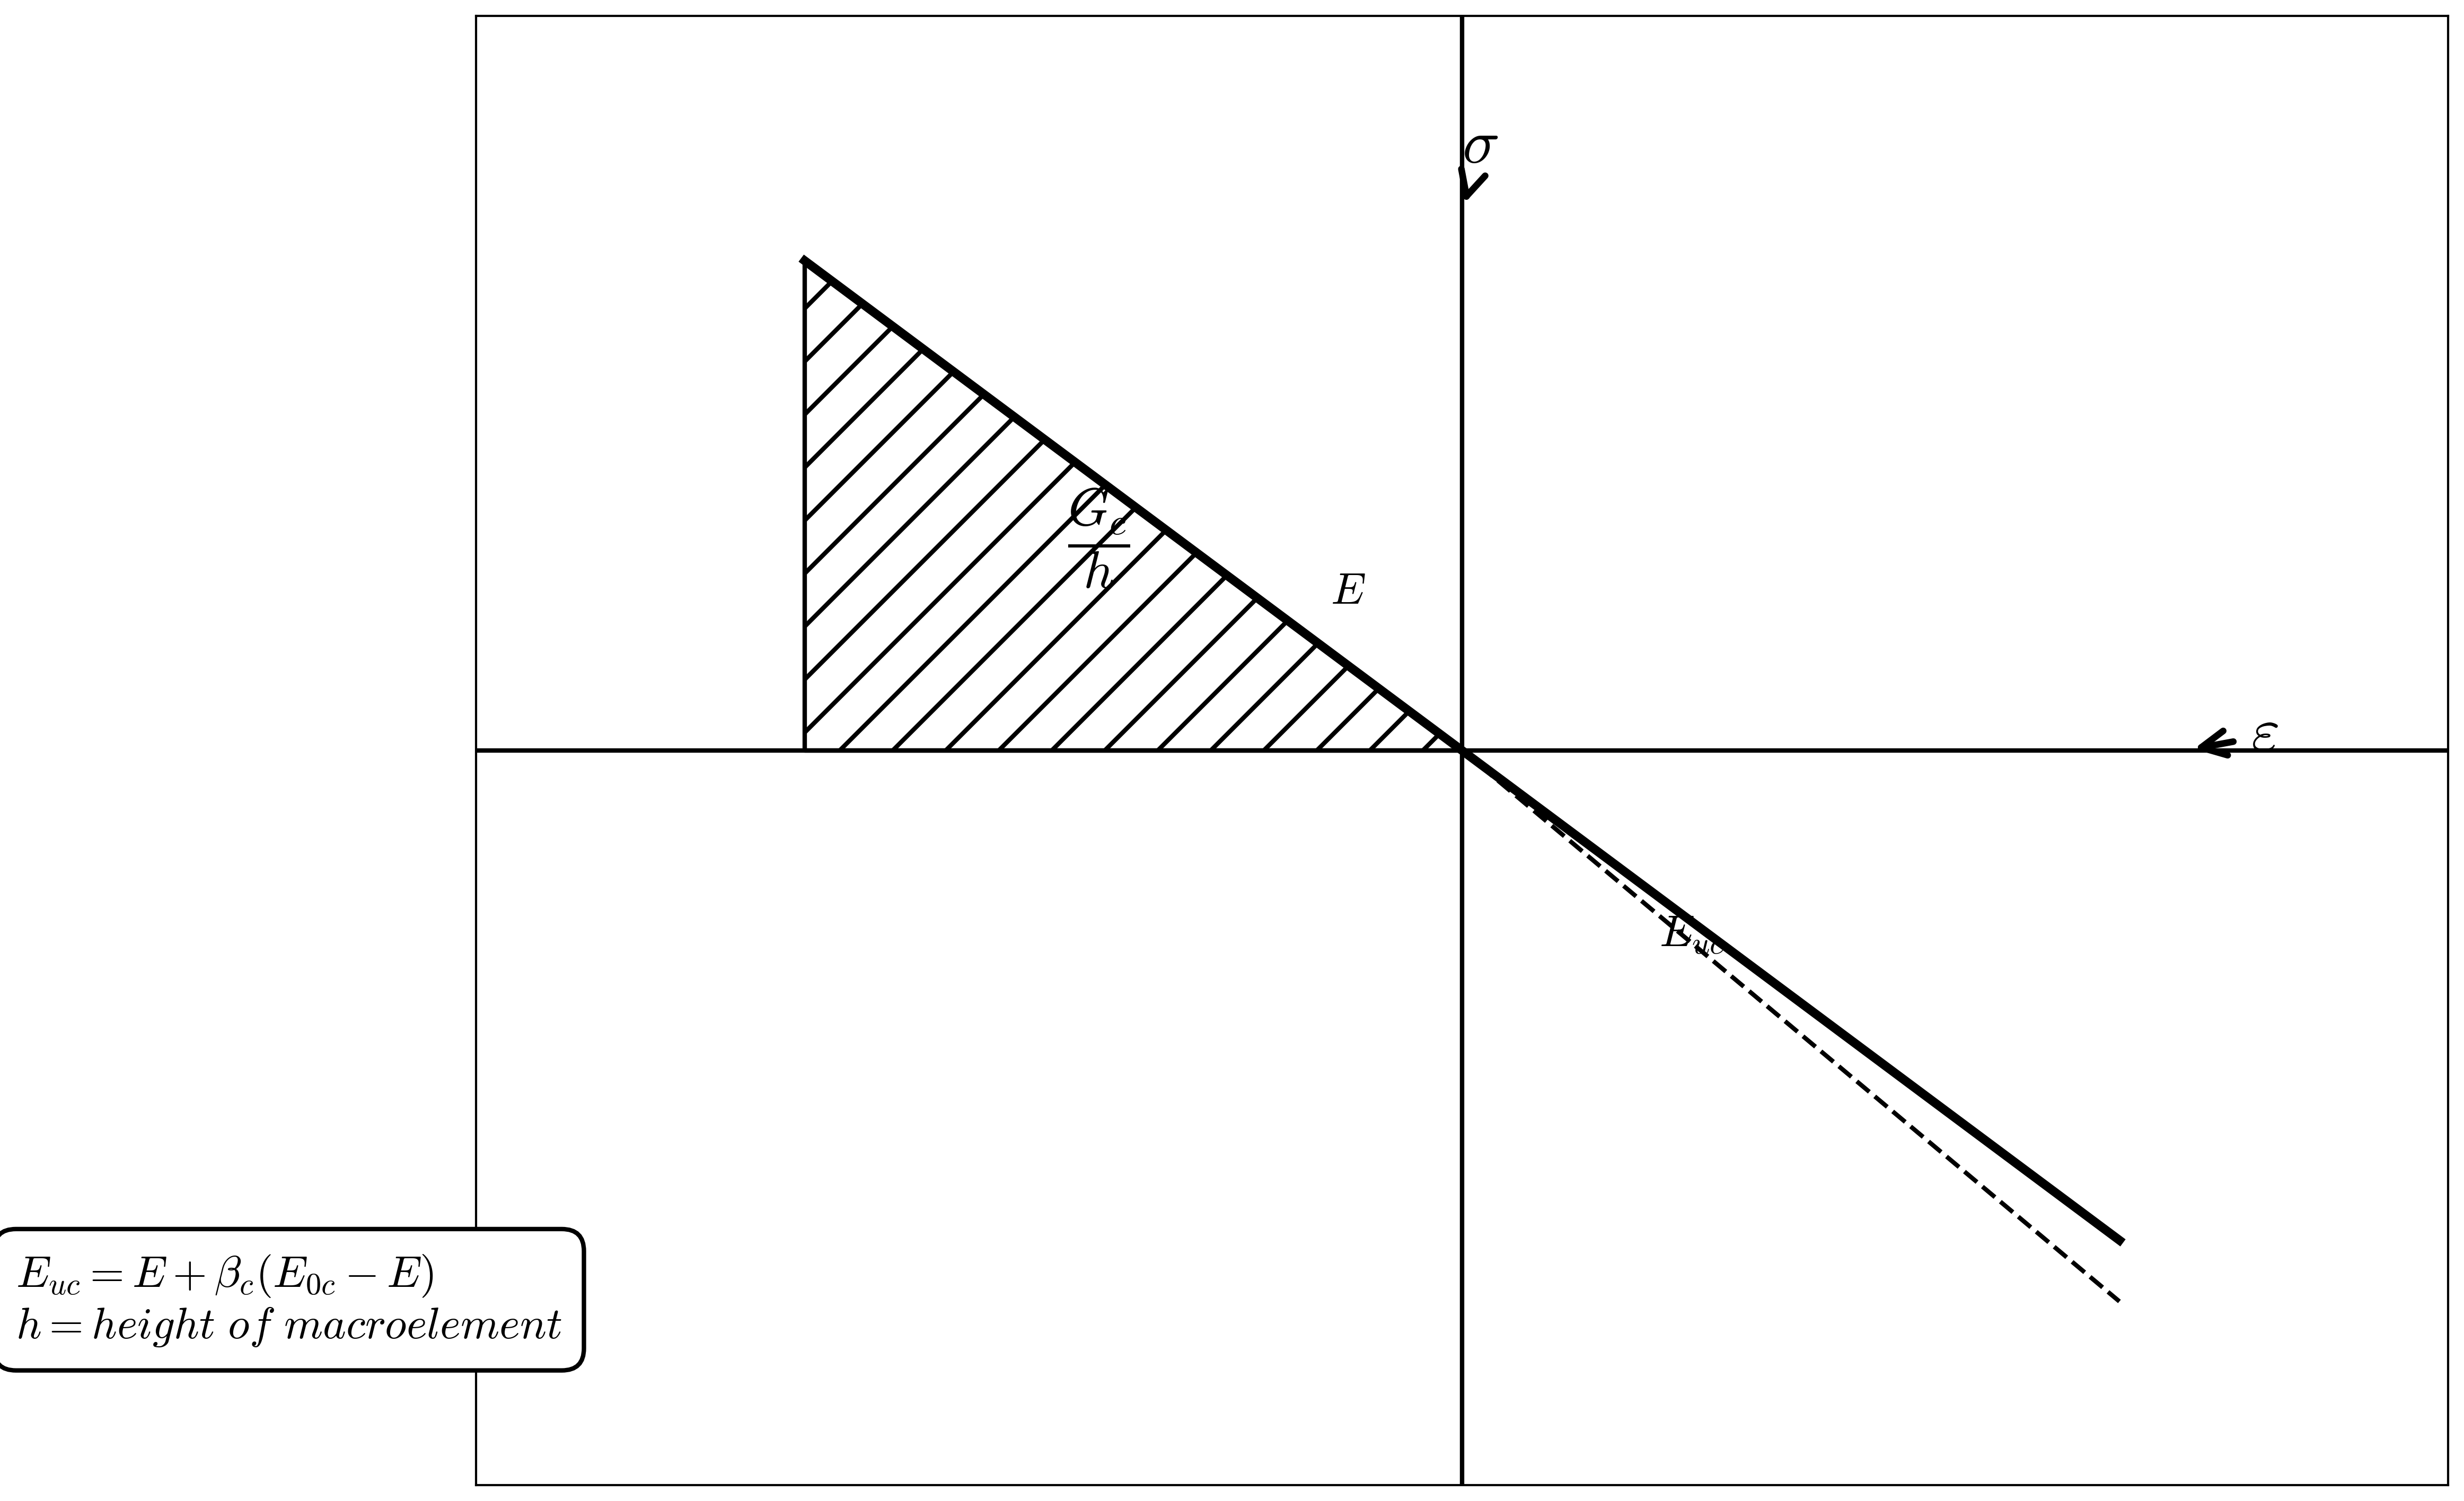

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
E = 200      # Initial modulus
E0c = 250    # Initial unloading modulus
beta_c = 0.5 # Factor for modulus reduction
G_c = 100    # Fracture energy
h = 10       # height of macroelement
sigma_yc = 50  # Yield stress
eps_yc = sigma_yc / E  # Yield strain

# Strain range for plotting the main triangle
eps = np.array([-eps_yc, 0, eps_yc])
sigma = np.array([sigma_yc, 0, -sigma_yc])

# Effective unloading modulus
E_uc = E + beta_c * (E0c - E)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the main triangular shape
ax.plot(eps, sigma, 'k', lw=2)

# Fill the left half with hatched pattern
ax.fill_between(eps[:2], sigma[:2], 0, hatch='//', edgecolor='black', facecolor='none')

# Plot the unloading slope line
eps_line = np.array([0, eps_yc])
sigma_line = np.array([0, -E_uc * eps_yc])  # Unloading slope
ax.plot(eps_line, sigma_line, 'k--', label=r'$E_{uc}$')

# Add Gc/h text (inside the hatched region)
ax.text(-0.6 * eps_yc, 0.4 * sigma_yc, r'$\dfrac{G_c}{h}$', fontsize=12)

# Equation box
ax.text(-2.2 * eps_yc, -1.2 * sigma_yc,
        r'$E_{uc} = E + \beta_c (E_{0c} - E)$' '\n' r'$h = height \ of \ macroelement$',
        fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Axis labels with arrows
ax.annotate(r'$\varepsilon$', xy=(1.1 * eps_yc, 0), xytext=(1.2 * eps_yc, 0),
            arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=14)
ax.annotate(r'$\sigma$', xy=(0, 1.1 * sigma_yc), xytext=(0, 1.2 * sigma_yc),
            arrowprops=dict(arrowstyle="->", lw=1.5), fontsize=14)

# Add text labels for E and E_uc
ax.text(-0.2 * eps_yc, 0.3 * sigma_yc, r'$E$', fontsize=10)
ax.text(0.3 * eps_yc, -0.4 * sigma_yc, r'$E_{uc}$', fontsize=10)

# Axis setup
ax.set_xlim(-1.5 * eps_yc, 1.5 * eps_yc)
ax.set_ylim(-1.5 * sigma_yc, 1.5 * sigma_yc)
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

ax.set_xticks([])
ax.set_yticks([])

plt.show()
